# Imports and Preprocessing

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

analysis_dir = "/accounts/projects/jchayes/commnotes/commnotes-analysis/analysis"
os.chdir(analysis_dir)
sys.path.insert(0, analysis_dir)

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from linearmodels.panel import PanelOLS
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde, spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess

from src.data_loader import *
from src.analysis import *
from src.utils import *
from src.visualization import *
from src.visualization import (
    apply_publication_style,
    _setup_ax,
    _finalize,
    _C_BLUE,
    _C_ORANGE,
    _C_EVENT,
    _C_ZERO,
    _C_LIGHT,
    _C_PURPLE,
    _C_AMBER,
    _MUTED_PALETTE,
    _FONT_LEGEND,
    _FONT_ANNOT,
    _FONT_TICK,
    _FONT_LABEL,
)

In [4]:
# --- Configuration (Corrected Paths) ---
# Using the absolute paths from your working environment
NOTES_PATH = "/scratch/users/commnotes/communitynotes/sourcecode/notes-00000.tsv"
HISTORY_PATH = "/scratch/users/commnotes/communitynotes/sourcecode/noteStatusHistory-00000.tsv"
RATINGS_DIR = "/scratch/users/commnotes/communitynotes/sourcecode/ratings"
WEEKLY_OUTPUTS_PATH = "/scratch/users/commnotes/communitynotes2022/communitynotes/static/sourcecode/weekly_outputs"
WEEKLY_OUTPUTS_PATH_2025 = "/scratch/users/commnotes/communitynotes/sourcecode/weekly_outputs"


start_date = "2022-06-01"
max_date = "2023-06-01"

In [5]:
print("--- Loading and Preparing Data ---")
# This DataFrame contains data related to "notes" associated with tweets. It includes unique IDs for notes, authors, and tweets, along with
# timestamps, classifications (e.g., "MISINFORMED_OR_POTENTIALLY_MISLEADING"), and other
# attributes describing the history of the notes
notes_df = pd.read_csv(NOTES_PATH, sep='\\t', dtype={'noteAuthorParticipantId': str, 'tweetId': str, 'noteId': str})
notes_df["noteId"]=notes_df["noteId"].astype(int)

# The following is all note ratings published by X keeping the following columns: 
# "'noteId', 'raterParticipantId', 'createdAtMillis', 'helpfulnessLevel'" since we don't use the rest.
ratings_df = read_ratings_from_directory(RATINGS_DIR, start_date_str="2020-06-01",end_date_str=max_date)

# The following df is the results of the matrix factorization for both 2022 and 2025 version of the code.
note_df_full, rater_df, status_df, helpfulness_df, aux_df = load_weekly_outputs(WEEKLY_OUTPUTS_PATH,debug=False)
note_df_full_2025, rater_df_2025, status_df_2025, helpfulness_df_2025, aux_df_2025 = load_weekly_outputs(WEEKLY_OUTPUTS_PATH_2025,debug=False)

# This df is the history of all notes
history_df =   pd.read_csv(HISTORY_PATH, sep='\\t', dtype={'noteAuthorParticipantId': str, 'tweetId': str, 'noteId': str})

# The following df is notes with corresponding topics. Topics are modelled by the X topic modeling algorithm.
notes_df_topic = pd.read_csv("/accounts/projects/jchayes/commnotes/df_notes_with_topics.csv")

# The following df is notes with corresponding topics based on LLM topic modelers.
notes_df_llms = pd.read_csv("/accounts/projects/jchayes/commnotes/notes_llm_topic.csv")


notes_df_topic['noteId'] = notes_df_topic['noteId'].astype(int)

--- Loading and Preparing Data ---


/tmp/ipykernel_1538587/1959131124.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


Found 16 total rating files. Processing them in chunks to filter by date.


Reading ratings:  50%|█████     | 8/16 [01:03<01:08,  8.59s/it]Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f80afcdf8c0>>
Traceback (most recent call last):
  File "/usr/local/linux/miniforge-3.13/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
Loading weekly outputs: 100%|██████████| 84/84 [02:28<00:00,  1.77s/it]


note is loaded.
rater is loaded.
status is loaded.
helpfulness is loaded.
aux is loaded.


Loading weekly outputs: 100%|██████████| 44/44 [00:05<00:00,  7.55it/s]
/tmp/ipykernel_1538587/1959131124.py:17: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


note is loaded.
rater is loaded.
status is loaded.
key without data status
helpfulness is loaded.
key without data helpfulness
aux is loaded.
key without data aux


In [ ]:
ratings_df['createdAtDate'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms')

In [ ]:
rater_df_2025 = rater_df_2025.rename(columns={"internalRaterFactor1": "raterFactor1", "internalRaterIntercept": "raterIntercept"})
note_df_full_2025 = note_df_full_2025.rename(columns={"internalNoteFactor1": "noteFactor1", "internalNoteIntercept": "noteIntercept"})

In [ ]:
rollout_date = pd.to_datetime("2022-10-01")

In [ ]:
# get one cohort of legacy raters who were active before rollout date
legacy_users = ratings_df[ratings_df['createdAtDate'] < rollout_date]['raterParticipantId'].unique()

# get one cohort of new raters who joined between Oct. 2022 and Jan. 2023
new_users = ratings_df[(ratings_df['createdAtDate'] >= rollout_date) & (ratings_df['createdAtDate'] < pd.to_datetime("2023-01-01"))]['raterParticipantId'].unique()
new_users = [user for user in new_users if user not in legacy_users]

In [ ]:
len(legacy_users), len(new_users)

(1537, 6979)

In [ ]:
# restrict ratings data to June 2022 - June 2023
ratings_df = ratings_df[ratings_df['createdAtDate'] >= start_date]

# Main Text Figure 1

## Figure 1(a)


--- Slide 8 & 9: Factor Distribution Shifts ---


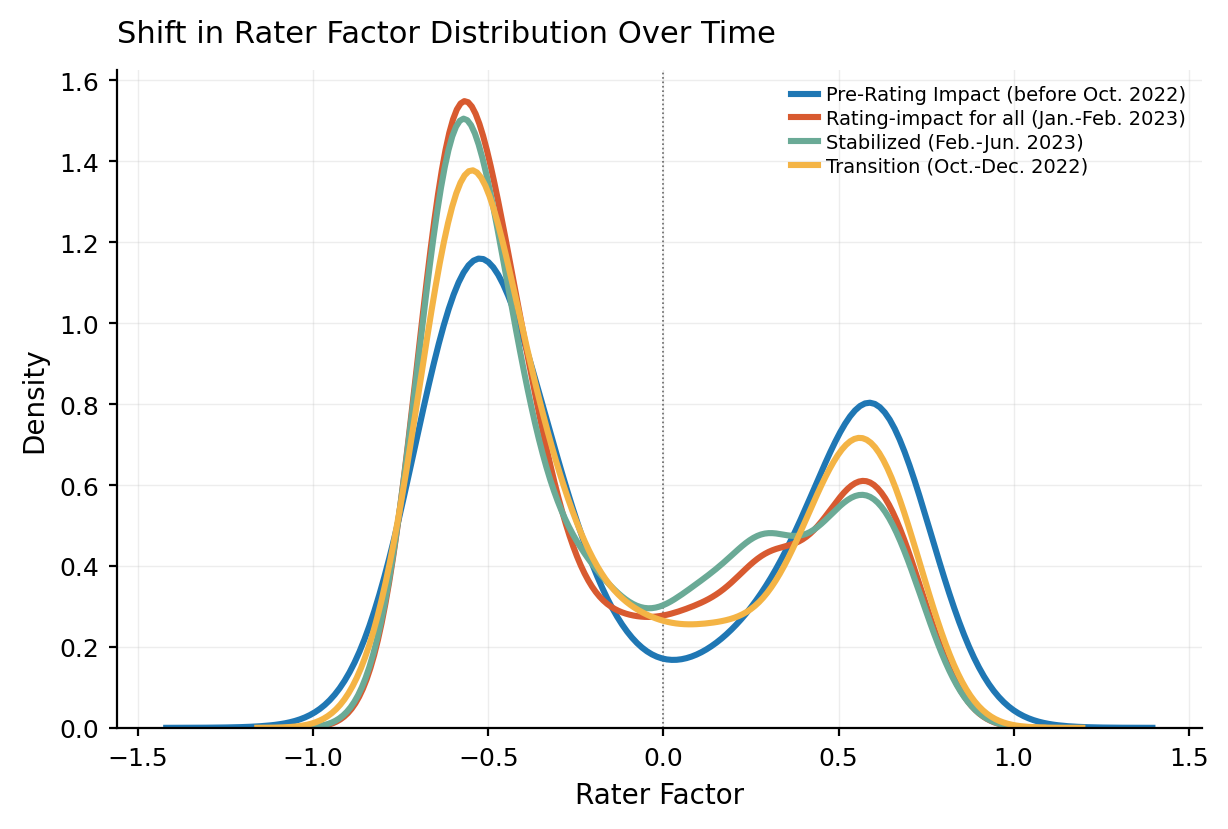

In [20]:
# Prepare common dataframes
latest_rater_factors = rater_df.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
latest_note_factors = note_df_full.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
rater_df['month_str'] = rater_df['week_dt'].dt.strftime('%Y-%m')
rater_df['phase'] = rater_df['month_str'].apply(assign_phase)

# Save the plot to /accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main
plot_factor_distribution_shifts(rater_df, 'raterFactor1', save_path='/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main/rater_factor_distribution_shift_2022.png')


## Figure 1(b)

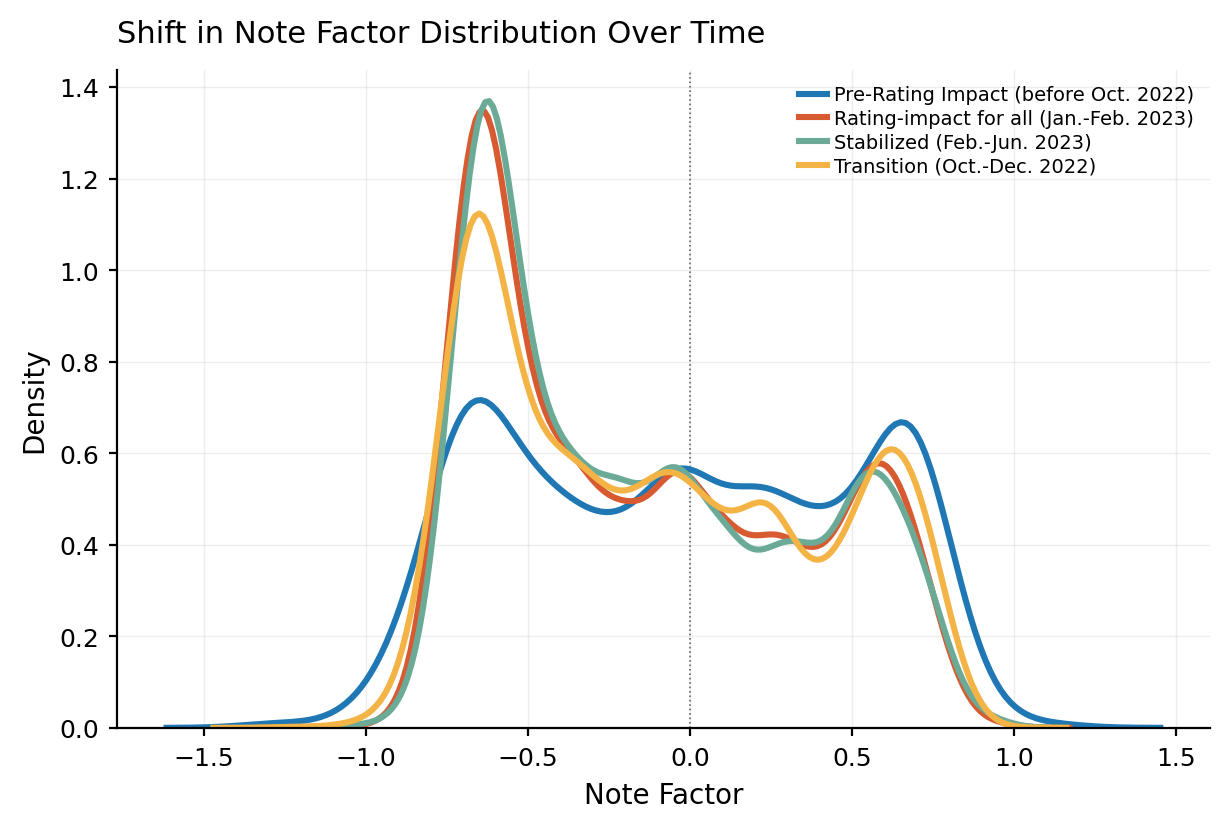

In [19]:
note_df_full['month_str'] = note_df_full['week_dt'].dt.strftime('%Y-%m')
note_df_full['phase'] = note_df_full['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(note_df_full, 'noteFactor1', save_path='/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main/note_factor_distribution_shift_2022.png')

# (i) Latent Factor Distribution Shift Numbers

In [21]:
def factor_sign_percentages(df, factor_col, label):
    """
    Percent of raw factor values above/below zero for each plotted phase.
    Exact zeros are excluded from the denominator.
    """
    d = df[["phase", factor_col]].copy()
    d[factor_col] = pd.to_numeric(d[factor_col], errors="coerce")
    d = d.dropna(subset=["phase", factor_col])
    d = d[d[factor_col] != 0]

    out = (
        d.assign(
            minority=d[factor_col] > 0,
            majority=d[factor_col] < 0,
        )
        .groupby("phase", as_index=False)
        .agg(
            n_factors=(factor_col, "size"),
            n_minority=("minority", "sum"),
            n_majority=("majority", "sum"),
        )
    )

    out["pct_minority_gt_0"] = 100 * out["n_minority"] / out["n_factors"]
    out["pct_majority_lt_0"] = 100 * out["n_majority"] / out["n_factors"]
    out.insert(0, "curve", label)

    return out[
        [
            "curve",
            "phase",
            "n_factors",
            "n_minority",
            "pct_minority_gt_0",
            "n_majority",
            "pct_majority_lt_0",
        ]
    ]


fig1_factor_signs = pd.concat(
    [
        factor_sign_percentages(rater_df, "raterFactor1", "Figure 1a: rater factors"),
        factor_sign_percentages(note_df_full, "noteFactor1", "Figure 1b: note factors"),
    ],
    ignore_index=True,
)

fig1_factor_signs

,curve,phase,n_factors,n_minority,pct_minority_gt_0,n_majority,pct_majority_lt_0
0,Figure 1a: rater factors,Pre-Rating Impact (before Oct. 2022),878,365,41.571754,513,58.428246
1,Figure 1a: rater factors,Rating-impact for all (Jan.-Feb. 2023),6295,2247,35.694996,4048,64.305004
2,Figure 1a: rater factors,Stabilized (Feb.-Jun. 2023),6273,2313,36.872310,3960,63.127690
3,Figure 1a: rater factors,Transition (Oct.-Dec. 2022),3791,1371,36.164600,2420,63.835400
4,Figure 1b: note factors,Pre-Rating Impact (before Oct. 2022),3462,1635,47.227036,1827,52.772964
5,Figure 1b: note factors,Rating-impact for all (Jan.-Feb. 2023),22543,8178,36.277337,14365,63.722663
6,Figure 1b: note factors,Stabilized (Feb.-Jun. 2023),22232,7970,35.849226,14262,64.150774
7,Figure 1b: note factors,Transition (Oct.-Dec. 2022),13852,5421,39.135143,8431,60.864857


In [22]:
def mean_abs_factor_by_phase(df, factor_col, label=None):
    """
    Compute mean absolute factor within majority (<0) and minority (>0)
    for each phase, using the raw observations in the dataframe.

    Exact zeros are excluded.
    """
    d = df.copy()

    if "phase" not in d.columns:
        d["month_str"] = pd.to_datetime(d["week_dt"]).dt.strftime("%Y-%m")
        d["phase"] = d["month_str"].apply(assign_phase)

    d[factor_col] = pd.to_numeric(d[factor_col], errors="coerce")
    d = d.dropna(subset=["phase", factor_col])
    d = d[d[factor_col] != 0].copy()

    d["alignment"] = np.where(d[factor_col] > 0, "minority", "majority")
    d["abs_factor"] = d[factor_col].abs()

    out = (
        d.groupby(["phase", "alignment"], as_index=False)
        .agg(
            n_factors=(factor_col, "size"),
            mean_abs_factor=("abs_factor", "mean"),
            sd_abs_factor=("abs_factor", "std"),
            se_abs_factor=("abs_factor", lambda x: x.std(ddof=1) / np.sqrt(x.size)),
        )
    )

    out["ci95_low"] = out["mean_abs_factor"] - 1.96 * out["se_abs_factor"]
    out["ci95_high"] = out["mean_abs_factor"] + 1.96 * out["se_abs_factor"]
    out["ci95_pm"] = 1.96 * out["se_abs_factor"]

    if label is not None:
        out.insert(0, "curve", label)

    return out.sort_values(["phase", "alignment"]).reset_index(drop=True)


rater_mean_abs_by_phase = mean_abs_factor_by_phase(
    rater_df,
    "raterFactor1",
    label="Figure 1a: rater factors",
)

note_mean_abs_by_phase = mean_abs_factor_by_phase(
    note_df_full,
    "noteFactor1",
    label="Figure 1b: note factors",
)

fig1_mean_abs_by_phase = pd.concat(
    [rater_mean_abs_by_phase, note_mean_abs_by_phase],
    ignore_index=True,
)

fig1_mean_abs_by_phase

,curve,phase,alignment,n_factors,mean_abs_factor,sd_abs_factor,se_abs_factor,ci95_low,ci95_high,ci95_pm
0,Figure 1a: rater factors,Pre-Rating Impact (before Oct. 2022),majority,513,0.489278,0.157341,0.006947,0.475663,0.502894,0.013616
1,Figure 1a: rater factors,Pre-Rating Impact (before Oct. 2022),minority,365,0.522398,0.177172,0.009274,0.504222,0.540574,0.018176
2,Figure 1a: rater factors,Rating-impact for all (Jan.-Feb. 2023),majority,4048,0.492126,0.166900,0.002623,0.486984,0.497267,0.005142
3,Figure 1a: rater factors,Rating-impact for all (Jan.-Feb. 2023),minority,2247,0.432045,0.211831,0.004469,0.423286,0.440803,0.008759
4,Figure 1a: rater factors,Stabilized (Feb.-Jun. 2023),majority,3960,0.489123,0.173331,0.002754,0.483724,0.494522,0.005399
5,Figure 1a: rater factors,Stabilized (Feb.-Jun. 2023),minority,2313,0.413118,0.215403,0.004479,0.404339,0.421896,0.008778
6,Figure 1a: rater factors,Transition (Oct.-Dec. 2022),majority,2420,0.479013,0.179689,0.003653,0.471854,0.486173,0.007159
7,Figure 1a: rater factors,Transition (Oct.-Dec. 2022),minority,1371,0.473014,0.196116,0.005297,0.462633,0.483395,0.010381
8,Figure 1b: note factors,Pre-Rating Impact (before Oct. 2022),majority,1827,0.468982,0.271262,0.006346,0.456544,0.481421,0.012439
9,Figure 1b: note factors,Pre-Rating Impact (before Oct. 2022),minority,1635,0.451912,0.249615,0.006173,0.439812,0.464011,0.012100


In [175]:
target_phases = [
    "Pre-Rating Impact (before Oct. 2022)",
    "Stabilized (Feb.-Jun. 2023)",
]

fig1_pre_and_stabilized = (
    fig1_mean_abs_by_phase
    .loc[
        fig1_mean_abs_by_phase["phase"].isin(target_phases)
        & fig1_mean_abs_by_phase["curve"].isin([
            "Figure 1a: rater factors",
            "Figure 1b: note factors",
        ])
    ]
    .sort_values(["curve", "phase", "alignment"])
    .reset_index(drop=True)
)

fig1_pre_and_stabilized

,curve,phase,alignment,n_factors,mean_abs_factor,sd_abs_factor,se_abs_factor,ci95_low,ci95_high,ci95_pm
0,Figure 1a: rater factors,Pre-Rating Impact (before Oct. 2022),majority,513,0.489278,0.157341,0.006947,0.475663,0.502894,0.013616
1,Figure 1a: rater factors,Pre-Rating Impact (before Oct. 2022),minority,365,0.522398,0.177172,0.009274,0.504222,0.540574,0.018176
2,Figure 1a: rater factors,Stabilized (Feb.-Jun. 2023),majority,3960,0.489123,0.173331,0.002754,0.483724,0.494522,0.005399
3,Figure 1a: rater factors,Stabilized (Feb.-Jun. 2023),minority,2313,0.413118,0.215403,0.004479,0.404339,0.421896,0.008778
4,Figure 1b: note factors,Pre-Rating Impact (before Oct. 2022),majority,1827,0.468982,0.271262,0.006346,0.456544,0.481421,0.012439
5,Figure 1b: note factors,Pre-Rating Impact (before Oct. 2022),minority,1635,0.451912,0.249615,0.006173,0.439812,0.464011,0.012100
6,Figure 1b: note factors,Stabilized (Feb.-Jun. 2023),majority,14262,0.464456,0.224485,0.001880,0.460772,0.468141,0.003684
7,Figure 1b: note factors,Stabilized (Feb.-Jun. 2023),minority,7970,0.408290,0.232818,0.002608,0.403179,0.413402,0.005111


In [25]:
# Measure the difference in factor shift for legacy vs. new users
# between Oct. 1, 2022 and Jan. 1, 2023.
def compute_factor_shift(df, user_list, factor_col):
    df = df.copy()
    df["week_dt"] = pd.to_datetime(df["week_dt"])

    # First factor after Oct. 1, 2022
    first_df = (
        df[
            (df["raterParticipantId"].isin(user_list)) &
            (df["week_dt"] > pd.Timestamp("2022-10-01"))
        ]
        .sort_values("week_dt")
        .groupby("raterParticipantId", as_index=False)
        .first()
        [["raterParticipantId", factor_col]]
        .rename(columns={factor_col: "first_factor"})
    )

    # First factor after Jan. 1, 2023
    last_df = (
        df[
            (df["raterParticipantId"].isin(user_list)) &
            (df["week_dt"] > pd.Timestamp("2023-01-01"))
        ]
        .sort_values("week_dt")
        .groupby("raterParticipantId", as_index=False)
        .first()
        [["raterParticipantId", factor_col]]
        .rename(columns={factor_col: "last_factor"})
    )

    # Merge and compute shift
    out = first_df.merge(last_df, on="raterParticipantId", how="inner")
    out["factor_shift"] = out["last_factor"] - out["first_factor"]

    return out

In [ ]:
# permutation test for whether legacy users and different factor shift than new users
def perm_test(x, y, n_perm=10_000, seed=0, stat=np.mean):
    x = np.asarray(x)
    y = np.asarray(y)

    obs = stat(x) - stat(y)

    combined = np.concatenate([x, y])
    n_x = len(x)

    rng = np.random.default_rng(seed)
    perm = np.empty(n_perm)

    for i in range(n_perm):
        rng.shuffle(combined)
        perm[i] = stat(combined[:n_x]) - stat(combined[n_x:])

    p = (np.abs(perm) >= np.abs(obs)).mean()
    return obs, p

    

In [26]:
legacy_shift_2022 = compute_factor_shift(rater_df, legacy_users, "raterFactor1")
new_shift_2022 = compute_factor_shift(rater_df, new_users, "raterFactor1")
perm_test(legacy_shift_2022['factor_shift'], new_shift_2022['factor_shift'])

(np.float32(-0.050643813), np.float64(0.0))

# Main Text Figure 2

In [12]:
def prepare_rating_factors_over_time_weekly(ratings_df, note_df, rater_df):
    # Add week column to ratings
    rater_df['week_dt'] = pd.to_datetime(rater_df['week_dt']).dt.normalize()
    note_df['week_dt'] = pd.to_datetime(note_df['week_dt']).dt.normalize()
    ratings_df['week_dt'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms').dt.to_period('W').dt.start_time

    
    # Ensure note_df and rater_df also have 'week' column
    if 'week_dt' not in note_df.columns or 'week_dt' not in rater_df.columns:
        raise ValueError("note_df and rater_df must include a 'week' column for weekly merging.")
    
    ratings_df = ratings_df.sort_values(['week_dt'])
    note_df = note_df.sort_values([ 'week_dt'])
    rater_df = rater_df.sort_values(["week_dt"])

    # Merge_asof for note factors
    df = pd.merge_asof(
        ratings_df,
        note_df[['noteId', 'noteFactor1', 'noteIntercept', 'week_dt']],
        by='noteId',
        left_on='week_dt',
        right_on='week_dt',
        direction='backward',
        allow_exact_matches=False
    )

    # Ensure participant IDs are the same type (string is usually safest)
    rater_df["raterParticipantId"] = rater_df["raterParticipantId"].astype(str)
    df["raterParticipantId"] = df["raterParticipantId"].astype(str)
    
    # Merge with rater factors by raterParticipantId and week
    df = pd.merge_asof(
        left=df,
        right=rater_df[["raterParticipantId", "week_dt", "raterFactor1", 'raterIntercept']],
        by="raterParticipantId",
        left_on="week_dt",
        right_on="week_dt",
        direction="backward",
        allow_exact_matches=False
    )

    # Convert labels
    df['helpful_binary'] = np.where(
        df['helpfulnessLevel'] == 'HELPFUL', 1,
        np.where(df['helpfulnessLevel'] == 'NOT_HELPFUL', 0, np.nan)
    )

    # # Clean up
    df = df.dropna(subset=['noteFactor1', 'raterFactor1', 'helpful_binary'])

    # Label for coloring
    df['vote_label'] = df['helpful_binary'].map({1: 'Helpful', 0: 'Not Helpful'})

    return df


# Prepare data
df_plot = prepare_rating_factors_over_time_weekly(ratings_df, note_df_full_2025, rater_df_2025)

In [13]:
start = '2022-08-01'
end = '2023-01-01'

cutoff = '2022-10-01'

df_plot['week_dt'] = pd.to_datetime(df_plot['week_dt'])
df_plot = df_plot[(df_plot['week_dt'] >= start) & (df_plot['week_dt'] <= end)]
df_plot['dot_product'] = df_plot["noteFactor1"] * df_plot["raterFactor1"]
df_plot_legacy = df_plot[df_plot['raterParticipantId'].isin(legacy_users)]

Corr before: 0.7921
Corr after: 0.5274
Observed diff: -0.2647


P-value: 0.0078


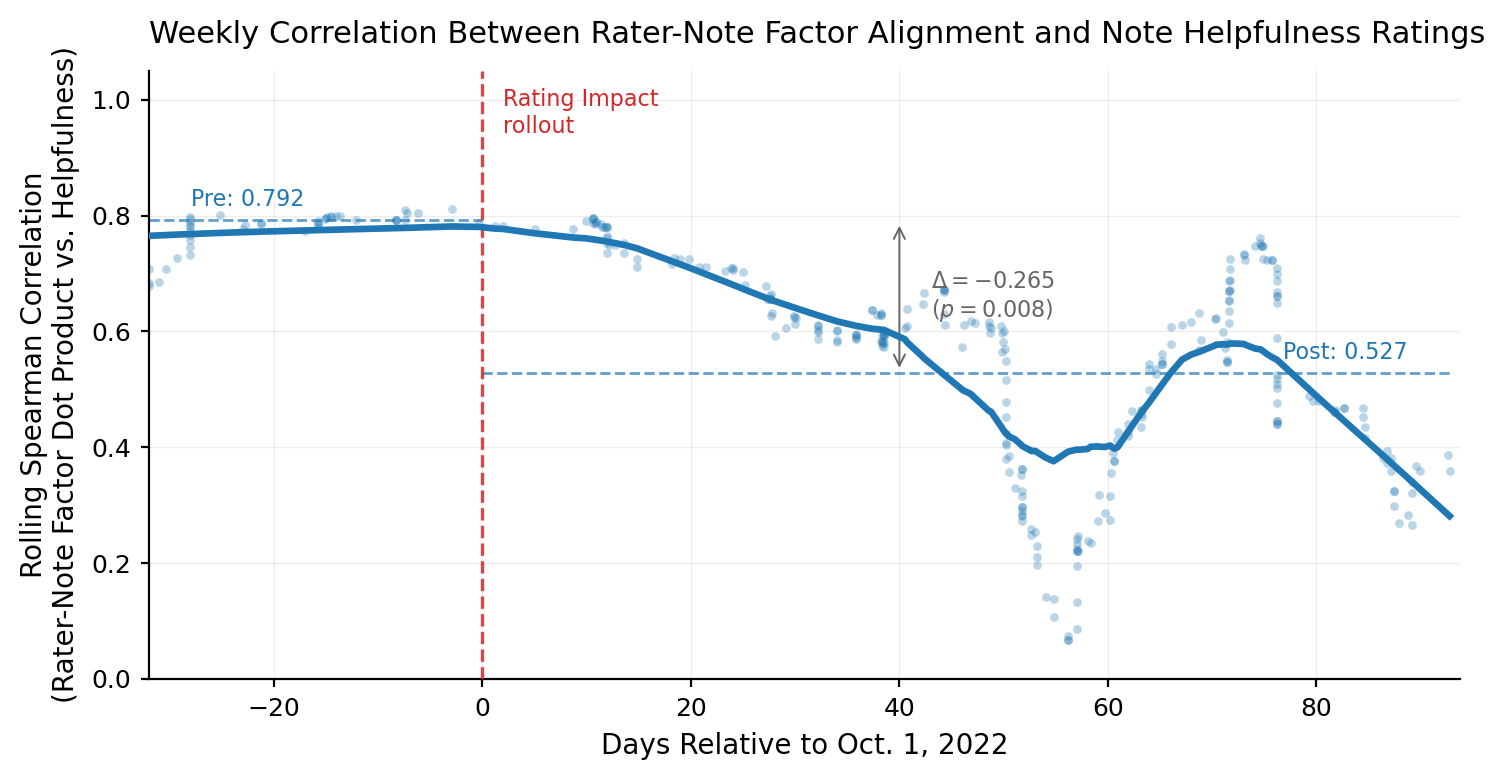

In [14]:
# Use the actual rating timestamp (not the week bucket) so points spread over time.
df_plot_legacy = df_plot_legacy.copy()
df_plot_legacy["rating_dt"] = pd.to_datetime(df_plot_legacy["createdAtMillis"], unit="ms")
df_plot_legacy = df_plot_legacy.sort_values("rating_dt").reset_index(drop=True)

# Compute the average spearman r between notehelpfulness and the dot product of rater factor * note factor
before = df_plot_legacy[df_plot_legacy['week_dt'] < cutoff]
after = df_plot_legacy[df_plot_legacy['week_dt'] > cutoff]

corr_before = spearmanr(before['dot_product'], before['helpful_binary']).correlation
corr_after = spearmanr(after['dot_product'], after['helpful_binary']).correlation
observed_diff = corr_after - corr_before
print(f'Corr before: {corr_before:.4f}')
print(f'Corr after: {corr_after:.4f}')
print(f'Observed diff: {observed_diff:.4f}')

# Do a permutation test to compute a p-value
rng = np.random.default_rng(42)
all_data = pd.concat([before, after]).reset_index(drop=True)
n_before = len(before)
perm_diffs = []

for _ in range(10_000):
    shuffled = all_data.sample(frac=1).reset_index(drop=True)
    perm_before = shuffled.iloc[:n_before]
    perm_after = shuffled.iloc[n_before:]

    c_before = spearmanr(perm_before['dot_product'], perm_before['helpful_binary']).correlation
    c_after = spearmanr(perm_after['dot_product'], perm_after['helpful_binary']).correlation
    perm_diffs.append(c_after - c_before)

perm_diffs = np.array(perm_diffs)
p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f'P-value: {p_value:.4f}')



# plot rolling spearman
window = 50
min_periods = 20
rolling_spearman = []

for i in range(len(df_plot_legacy)):
    start_i = max(0, i - window)
    window_data = df_plot_legacy.iloc[start_i:i + 1]

    if len(window_data) < min_periods:
        rolling_spearman.append(np.nan)
    else:
        corr, _ = spearmanr(
            window_data["dot_product"],
            window_data["helpful_binary"],
        )
        rolling_spearman.append(corr)

df_plot_legacy["rolling_corr"] = rolling_spearman
df_plot_legacy["rolling_corr"] = df_plot_legacy["rolling_corr"].clip(-1, 1)

cutoff_dt = pd.to_datetime(cutoff)
# Continuous days (with fractional part) relative to cutoff, so x-positions vary within a week.
df_plot_legacy["days_rel"] = (
    (df_plot_legacy["rating_dt"] - cutoff_dt).dt.total_seconds() / 86400.0
)
valid = df_plot_legacy.dropna(subset=["rolling_corr", "days_rel"]).copy()

smoothed = lowess(
    valid["rolling_corr"].to_numpy(),
    valid["days_rel"].to_numpy(),
    frac=0.3,
    return_sorted=True,
)

pre_mean = corr_before
post_mean = corr_after
delta = observed_diff

apply_publication_style()
fig, ax = plt.subplots(figsize=(7.5, 4.0))

ax.scatter(
    valid["days_rel"],
    valid["rolling_corr"],
    color=_C_BLUE,
    alpha=0.30,
    s=10,
    linewidths=0,
    zorder=2,
)
ax.plot(smoothed[:, 0], smoothed[:, 1], color=_C_BLUE, linewidth=2.4, zorder=4)
ax.axvline(0, color=_C_EVENT, linewidth=1.2, linestyle="--", alpha=0.85, zorder=3)
ax.axhline(0, color=_C_ZERO, linewidth=0.5, linestyle=":", zorder=1)

ax.hlines(pre_mean, valid["days_rel"].min(), 0, color=_C_BLUE, linewidth=1.0, linestyle="--", alpha=0.7)
ax.hlines(post_mean, 0, valid["days_rel"].max(), color=_C_BLUE, linewidth=1.0, linestyle="--", alpha=0.7)

ax.text(valid["days_rel"].min() + 4, pre_mean + 0.025, f"Pre: {pre_mean:.3f}", fontsize=_FONT_ANNOT, color=_C_BLUE)
ax.text(valid["days_rel"].max() - 4, post_mean + 0.025, f"Post: {post_mean:.3f}", fontsize=_FONT_ANNOT, color=_C_BLUE, ha="right")

arrow_x = min(40, valid["days_rel"].max() - 5)
ax.annotate(
    "",
    xy=(arrow_x, post_mean),
    xytext=(arrow_x, pre_mean),
    arrowprops=dict(arrowstyle="<->", color=_C_ZERO, linewidth=0.7),
)
ax.text(
    arrow_x + 3,
    (pre_mean + post_mean) / 2,
    f"$\\Delta = {delta:.3f}$\n$(p = {p_value:.3f})$",
    color=_C_ZERO,
    fontsize=_FONT_ANNOT,
    ha="left",
    va="center",
)

ax.text(2, 1.02, "Rating Impact\nrollout", color=_C_EVENT, fontsize=_FONT_ANNOT, va="top")
ax.set_xlim(valid["days_rel"].min(), valid["days_rel"].max() + 1)
ax.set_ylim(0, 1.05)

_setup_ax(ax)
_finalize(
    fig,
    ax,
    xlabel="Days Relative to Oct. 1, 2022",
    ylabel="Rolling Spearman Correlation\n(Rater-Note Factor Dot Product vs. Helpfulness)",
    title="Weekly Correlation Between Rater-Note Factor Alignment and Note Helpfulness Ratings",
    save_path="/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main/spearman-correlation-visualization.png",
)


In [ ]:
apply_publication_style()
fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.hist(
    perm_diffs,
    bins=40,
    color=_C_BLUE,
    alpha=0.72,
    edgecolor="white",
    linewidth=0.4,
    label="Permutation differences",
)
ax.axvline(
    observed_diff,
    color=_C_EVENT,
    linestyle="--",
    linewidth=1.2,
    label=f"Observed difference ({observed_diff:.3f})",
)
ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc="upper right")
_setup_ax(ax)
_finalize(
    fig,
    ax,
    xlabel="Difference in Spearman Correlation",
    ylabel="Count",
    title="Permutation Test Statistic Distribution \nSpearman Correlation Before vs. After Rollout",
    save_path="/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/appendix/permutation_spearman.png",

# Main Text Figure 3

In [16]:
history_df["noteId"]=history_df["noteId"].astype(int)

CONTROVERSIAL_TOPICS = [
    'USPolitics', 'UkraineConflict', 'GazaConflict',
    'CrimeLegal', 'HealthCovid', 'EconomyFinance','MessiRonaldo',  'politics', 'economy', 'health'
]

NON_CONTROVERSIAL_TOPICS = [
    'SpaceAstronomy', 'ClimateEnvironment', 'EntertainmentMoviesTV',
    'WeatherDisasters', 'TechCompanies', 'SportsNFL', 'SportsNBA',
'FoodNutrition', 'Education', 'Scams',
    'ArtificialIntelligence', 'science', 'other'
]

notes_df_topic["controversial"] = np.select(
    [
        notes_df_topic['noteTopic'].isin(CONTROVERSIAL_TOPICS),
        notes_df_topic['noteTopic'].isin(NON_CONTROVERSIAL_TOPICS),
    ],
    ["Controversial", "Non-Controversial"],
    default=pd.NA,
)

In [17]:

# Use XBOW as primary topic source
TOPIC_SOURCE = "XBOW"
START_DATE = "2022-06-01"
END_DATE = "2023-06-01"


def _clean_topic_series(s):
    return (
        s.astype("string")
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
    )


def prepare_topic_notes(topic_source: str | None = None):
    """
    Return note-level metadata and the selected topic column.
    """
    topic_source = (TOPIC_SOURCE if topic_source is None else topic_source).upper()

    note_meta = notes_df[["noteId", "createdAtMillis", "tweetId"]].copy()
    note_meta["noteId"] = pd.to_numeric(note_meta["noteId"], errors="coerce").astype("Int64")

    if topic_source == "XBOW":
        labels = notes_df_topic[["noteId", "noteTopic"]].copy()
        labels = labels.rename(columns={"noteTopic": "selectedTopic"})
        labels["noteId"] = pd.to_numeric(labels["noteId"], errors="coerce").astype("Int64")

    elif topic_source in {"TOPIC", "LLAMA4"}:
        labels = notes_df_llms[["NOTEID", topic_source]].copy()
        labels = labels.rename(columns={"NOTEID": "noteId", topic_source: "selectedTopic"})
        labels["noteId"] = pd.to_numeric(labels["noteId"], errors="coerce").astype("Int64")

    else:
        raise ValueError("TOPIC_SOURCE must be one of 'XBOW', 'TOPIC', or 'LLAMA4'.")

    labels = labels.dropna(subset=["noteId"]).drop_duplicates("noteId").copy()
    labels["selectedTopic"] = _clean_topic_series(labels["selectedTopic"])

    topic_notes = labels.merge(note_meta, on="noteId", how="left")
    return topic_notes, "selectedTopic"


topic_notes_df, topic_col = prepare_topic_notes(TOPIC_SOURCE)
print(f"Using {TOPIC_SOURCE} topic labels from `{topic_col}`.")

# Proportion of controversial vs. non-controversial NEW notes
# from June 1, 2022 through June 1, 2023.
topic_notes_window = topic_notes_df.copy()
topic_notes_window["createdAtDate"] = pd.to_datetime(topic_notes_window["createdAtMillis"], unit="ms")

topic_notes_window = topic_notes_window[
    (topic_notes_window["createdAtDate"] >= pd.to_datetime(START_DATE)) &
    (topic_notes_window["createdAtDate"] < pd.to_datetime(END_DATE))
].copy()

topic_values = _clean_topic_series(topic_notes_window[topic_col])
topic_notes_window["controversy_label"] = np.select(
    [
        topic_values.isin(set(CONTROVERSIAL_TOPICS)),
        topic_values.isin(set(NON_CONTROVERSIAL_TOPICS)),
    ],
    ["Controversial", "Non-Controversial"],
    default=pd.NA,
)

n_total = len(topic_notes_window)
n_labeled = topic_notes_window["controversy_label"].notna().sum()
n_unlabeled = topic_notes_window["controversy_label"].isna().sum()

print(f"Total NEW notes in window: {n_total:,}")
print(f"Labeled controversial/non-controversial: {n_labeled:,} ({n_labeled / n_total:.2%})")
print(f"Unlabeled/other: {n_unlabeled:,} ({n_unlabeled / n_total:.2%})")

controversy_counts = (
    topic_notes_window
    .dropna(subset=["controversy_label"])
    ["controversy_label"]
    .value_counts()
)

controversy_summary = pd.DataFrame({
    "count": controversy_counts,
    "proportion_among_labeled": controversy_counts / controversy_counts.sum(),
})

print(controversy_summary)


Using XBOW topic labels from `selectedTopic`.
Total NEW notes in window: 4,554
Labeled controversial/non-controversial: 4,554 (100.00%)
Unlabeled/other: 0 (0.00%)
                   count  proportion_among_labeled
controversy_label                                 
Controversial       3708                  0.814229
Non-Controversial    846                  0.185771


In [18]:
def _wilson_ci(k, n, z=1.96):
    """Wilson score interval for a binomial proportion."""
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        phat = np.where(n > 0, k / n, np.nan)
        denom = 1 + z**2 / n
        center = (phat + (z**2) / (2*n)) / denom
        margin = (z * np.sqrt((phat*(1-phat)/n) + (z**2)/(4*n**2))) / denom
        lo = center - margin
        hi = center + margin
    return lo, hi

def _weighted_centered_rolling(values, weights, window):
    """Centered, weight-aware rolling mean (nan-safe)."""
    s = pd.Series(values, dtype=float)
    w = pd.Series(weights, dtype=float)
    def _avg(x):
        v = x.values
        ww = w.iloc[x.index].values
        mask = ~np.isnan(v) & ~np.isnan(ww) & (ww > 0)
        return np.average(v[mask], weights=ww[mask]) if mask.any() else np.nan
    return s.rolling(window=window, center=True, min_periods=1).apply(_avg, raw=False)

In [19]:
def calculate_controversy_proportions_principled(
    status_history_df: pd.DataFrame,
    notes_df: pd.DataFrame,
    note_topic_col: str='noteTopic',
    time: str = "W",
    min_n: int = 30,               # hide points with fewer than min_n denominators
    smooth_window: int = 7,        # centered window length for smoothing
    jeffreys_alpha: float = 0.5,   # Jeffreys prior for shrinkage
    jeffreys_beta: float = 0.5
) -> pd.DataFrame:
    """
    Weekly proportions by topic category with:
      - category-specific denominators (unique tweets seeing their first note in that category)
      - Jeffreys-shrunk proportions to stabilize small n
      - Wilson 95% CIs
      - weighted, centered rolling smoothing (by denominator)
      - NaN where denominator < min_n (kept for plotting masks)
    """
    # Merge & prepare. 
    df = pd.merge(status_history_df, notes_df, on='noteId', how='right',
                  suffixes=('_status', '_note'))

    created_col = 'createdAtMillis_note' if 'createdAtMillis_note' in df.columns else 'createdAtMillis'
    tweet_col = 'tweetId_note' if 'tweetId_note' in df.columns else 'tweetId'

    df['note_creation_dt'] = pd.to_datetime(df[created_col], unit='ms')

    topic_values = _clean_topic_series(df[note_topic_col])
    df['topic_category'] = np.select(
        [
            topic_values.isin(set(CONTROVERSIAL_TOPICS)),
            topic_values.isin(set(NON_CONTROVERSIAL_TOPICS)),
        ],
        ['Controversial', 'Non-Controversial'],
        default='Other',
    )

    out = []

    for category in df['topic_category'].dropna().unique():
        cdf = df[df['topic_category'] == category]

        # denominator: first time each tweet gets ANY note in this category
        denom_idx = cdf.groupby(tweet_col)['note_creation_dt'].min()
        denom = denom_idx.value_counts().resample(time).sum().fillna(0).rename('denominator_tweets')

        # helpful / unhelpful: first time each tweet gets a note with that final status in this category
        helpful_first = (
            cdf[cdf['currentStatus'] == 'CURRENTLY_RATED_HELPFUL']
            .groupby(tweet_col)['note_creation_dt']
            .min()
        )
        unhelpful_first = (
            cdf[cdf['currentStatus'] == 'CURRENTLY_RATED_NOT_HELPFUL']
            .groupby(tweet_col)['note_creation_dt']
            .min()
        )

        helpful = helpful_first.value_counts().resample(time).sum().reindex(denom.index).fillna(0).rename(f'helpful_{category}')
        unhelpful = unhelpful_first.value_counts().resample(time).sum().reindex(denom.index).fillna(0).rename(f'unhelpful_{category}')

        # raw proportions (nan where n=0)
        with np.errstate(divide='ignore', invalid='ignore'):
            p_help = np.where(denom.values > 0, helpful.values / denom.values, np.nan)
            p_unhl = np.where(denom.values > 0, unhelpful.values / denom.values, np.nan)

        # Jeffreys-shrunk estimates
        ph_shrunk = (helpful.values + jeffreys_alpha) / (denom.values + jeffreys_alpha + jeffreys_beta)
        pu_shrunk = (unhelpful.values + jeffreys_alpha) / (denom.values + jeffreys_alpha + jeffreys_beta)
        ph_shrunk = np.where(denom.values > 0, ph_shrunk, np.nan)
        pu_shrunk = np.where(denom.values > 0, pu_shrunk, np.nan)

        # Wilson CIs (on raw proportions)
        ph_lo, ph_hi = _wilson_ci(helpful.values, denom.values)
        pu_lo, pu_hi = _wilson_ci(unhelpful.values, denom.values)

        # mask tiny denominators
        mask = denom.values >= min_n
        def _mask(arr):
            arr = np.asarray(arr, dtype=float)
            arr[~mask] = np.nan
            return arr

        # smooth (weighted by denominators)
        ph_smooth = _weighted_centered_rolling(_mask(ph_shrunk), denom.values, smooth_window)
        pu_smooth = _weighted_centered_rolling(_mask(pu_shrunk), denom.values, smooth_window)

        cat_df = pd.DataFrame({
            'week_dt': denom.index,
            'denominator_tweets_' + category: denom.values,
            f'helpful_{category}': helpful.values,
            f'unhelpful_{category}': unhelpful.values,
            f'prop_helpful_raw_{category}': _mask(p_help),
            f'prop_unhelpful_raw_{category}': _mask(p_unhl),
            f'prop_helpful_shrunk_{category}': _mask(ph_shrunk),
            f'prop_unhelpful_shrunk_{category}': _mask(pu_shrunk),
            f'prop_helpful_lo_{category}': _mask(ph_lo),
            f'prop_helpful_hi_{category}': _mask(ph_hi),
            f'prop_unhelpful_lo_{category}': _mask(pu_lo),
            f'prop_unhelpful_hi_{category}': _mask(pu_hi),
            f'prop_helpful_smooth_{category}': ph_smooth.values,
            f'prop_unhelpful_smooth_{category}': pu_smooth.values,
        })
        out.append(cat_df)

    # outer-merge all categories on week_dt
    result = out[0]
    for k in out[1:]:
        result = pd.merge(result, k, on='week_dt', how='outer')

    result = result.sort_values('week_dt').reset_index(drop=True)
    return df, result


In [20]:

# Compute controversy proportions using the selected topic source.
l_df, p_df = calculate_controversy_proportions_principled(
    history_df,
    topic_notes_df,
    note_topic_col=topic_col,
    time="W",
    min_n=5,
    smooth_window=9,
)


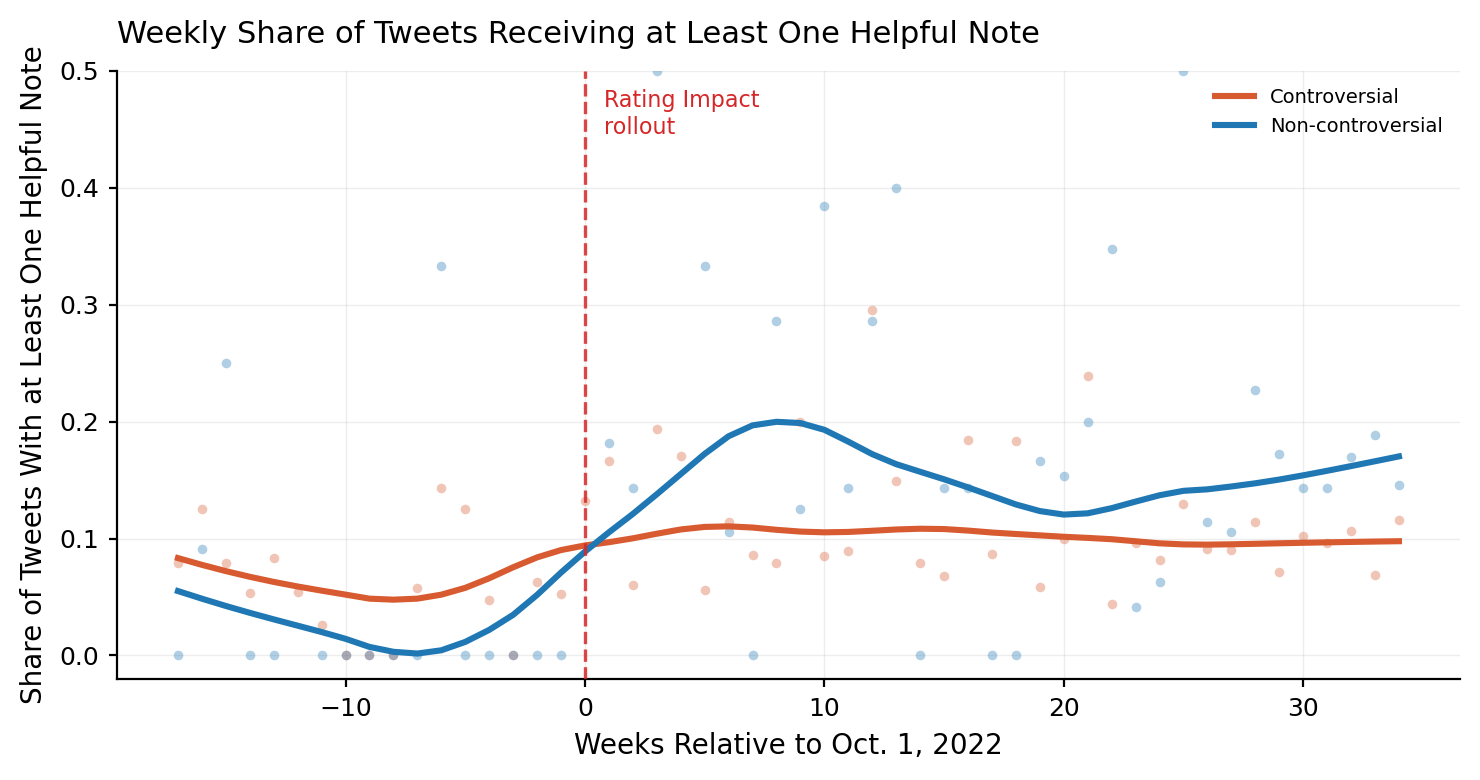

In [21]:
def plot_weekly_helpful_attainment_by_controversy(
    p_df,
    cutoff_date="2022-10-01",
    date_range=("2022-06-01", "2023-06-01"),
    categories=("Controversial", "Non-Controversial"),
    labels=("Controversial", "Non-controversial"),
    colors=None,
    frac_lowess=0.35,
    n_boot=500,
    save_path="final_code/figures-pnas/weekly_helpful_attainment_by_controversy.png",
    title="Weekly Share of Tweets Receiving at Least One Helpful Note",
):
    if colors is None:
        colors = [_C_ORANGE, _C_BLUE]

    cutoff = pd.to_datetime(cutoff_date)
    df = p_df.copy()
    df["week_dt"] = pd.to_datetime(df["week_dt"])
    df = df[
        (df["week_dt"] >= pd.to_datetime(date_range[0])) &
        (df["week_dt"] <= pd.to_datetime(date_range[1]))
    ].sort_values("week_dt")
    df["week_rel"] = ((df["week_dt"] - cutoff).dt.days / 7).round().astype(int)

    rng = np.random.default_rng(0)
    apply_publication_style()
    fig, ax = plt.subplots(figsize=(7.5, 4.0))

    for cat, label, color in zip(categories, labels, colors):
        n_col = f"denominator_tweets_{cat}"
        k_col = f"helpful_{cat}"

        # Raw weekly share of tweets receiving at least one Helpful note
        prop_col = f"prop_helpful_attainment_{cat}"
        df[prop_col] = np.where(
            df[n_col].fillna(0) > 0,
            df[k_col].fillna(0) / df[n_col],
            np.nan,
        )

        # prop_col = f"prop_helpful_attainment_{cat}"
        # df[prop_col] = np.where(df[n_col].fillna(0) > 0, df[k_col].fillna(0) / df[n_col], np.nan)

        sub = df[["week_rel", prop_col]].dropna()
        x = sub["week_rel"].to_numpy(dtype=float)
        y = sub[prop_col].to_numpy(dtype=float)

        ax.scatter(x, y, color=color, alpha=0.35, s=12, linewidths=0, zorder=2)
        sm = lowess(y, x, frac=frac_lowess, return_sorted=True)
        xs, ys = sm[:, 0], sm[:, 1]
        ax.plot(xs, ys, color=color, linewidth=2.2, label=label, zorder=4)

        boots = np.empty((n_boot, xs.size))
        for b in range(n_boot):
            idx = rng.integers(0, len(x), len(x))
            bsm = lowess(y[idx], x[idx], frac=frac_lowess, return_sorted=True)
            boots[b] = np.interp(xs, bsm[:, 0], bsm[:, 1])


    ax.axvline(0, color=_C_EVENT, linewidth=1.2, linestyle="--", alpha=0.85, zorder=5)
    ax.text(0.8, 0.97, "Rating Impact\nrollout", color=_C_EVENT, fontsize=_FONT_ANNOT, va="top", ha="left", transform=ax.get_xaxis_transform())
    
    ax.set_ylim(-0.02, 0.5)
    ax.set_yticks(np.arange(0, 0.51, 0.1))
    
    ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc="upper right")

    _setup_ax(ax)
    _finalize(
        fig,
        ax,
        xlabel="Weeks Relative to Oct. 1, 2022",
        ylabel="Share of Tweets With at Least One Helpful Note",
        title=title,
        save_path=save_path,
    )


plot_weekly_helpful_attainment_by_controversy(
    p_df,
    cutoff_date="2022-10-01",
    date_range=("2022-06-01", "2023-06-01"),
    save_path="/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main/weekly_helpful_attainment_by_controversy_raw_no_CI.png",
)

# Main Text Table 1

In [22]:
def _prepare_long_from_panel(panel_df, treated="Non-Controversial", control="Controversial",
                             min_n=30, use_jeffreys=True):
    """
    Returns long df with one row per (week, topic): week_dt, topic_type, prop, n_raw.
    prop uses Jeffreys smoothing for stability; n_raw is the raw denominator for weights.
    """
    df = panel_df.copy()
    df["week_dt"] = pd.to_datetime(df["week_dt"])

    out = []
    for topic in (treated, control):
        k_raw = df[f"helpful_{topic}"].astype(float)
        n_raw = df[f"denominator_tweets_{topic}"].astype(float)

        # Smoothed proportion for stability, but keep RAW n for weights
        if use_jeffreys:
            k = k_raw + 0.5
            n = n_raw + 1.0
        else:
            k, n = k_raw, n_raw

        prop = np.where(n_raw > 0, k / n, np.nan)
        keep = (n_raw >= min_n) & np.isfinite(prop)

        out.append(pd.DataFrame({
            "week_dt": df["week_dt"],
            "topic_type": topic,
            "prop": pd.Series(prop).where(keep),
            "n_raw": n_raw.where(keep)
        }))

    long_df = pd.concat(out, ignore_index=True).dropna(subset=["prop", "n_raw"])
    return long_df


def _weekly_diff_series(long_df, treated, control, weight_mode="min"):
    """
    Balanced weekly difference series:
      diff_t = prop_treated_t - prop_control_t
      w_t    = min(n_treated_t, n_control_t) or sum(...), per weight_mode.
    """
    wide = long_df.pivot(index="week_dt", columns="topic_type", values=["prop", "n_raw"])
    props = wide["prop"]
    ns = wide["n_raw"]

    if treated not in props or control not in props:
        raise ValueError("After filtering, one of the topics is missing. Check names and min_n.")

    # Keep only weeks where both are observed
    diff = (props[treated] - props[control]).dropna()
    n_t = ns[treated].reindex(diff.index)
    n_c = ns[control].reindex(diff.index)

    if weight_mode == "sum":
        w = (n_t + n_c).astype(float)
    else:  # default "min"
        w = np.minimum(n_t, n_c).astype(float)

    w = w.clip(lower=1.0)

    series = pd.DataFrame({"diff": diff.astype(float), "w": w.astype(float)})
    series.index.name = "week_dt"
    return series


def _fit_window(y, w, is_post, hac_maxlags=4):
    """
    WLS diff-in-means (pre vs post) with HAC standard errors.
    y, w, is_post can be numpy arrays or pandas Series.
    """
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)
    is_post = np.asarray(is_post, dtype=float)

    X = sm.add_constant(is_post)
    fit = sm.WLS(y, X, weights=w).fit(cov_type="HAC", cov_kwds={"maxlags": hac_maxlags})

    est = float(fit.params[1])
    se = float(fit.bse[1])
    p = float(fit.pvalues[1])
    z = 1.96
    ci = (est - z * se, est + z * se)
    return {"est": est, "se": se, "ci": ci, "p": p}


def did_windows_v2(panel_df,
                   change_date="2022-12-15",
                   treated="Non-Controversial",
                   control="Controversial",
                   pre_weeks=8,
                   short_post_weeks=8,
                   medium_post_weeks=(9, 26),
                   min_n=30,
                   use_jeffreys=True,
                   weight_mode="min",
                   hac_maxlags=4):
    """
    Short- and medium-run DiD on weekly helpfulness differences.
    Returns dict with 'short', 'medium', 'series', and 'meta'.
    """
    # Build balanced weekly diff series
    long_df = _prepare_long_from_panel(panel_df, treated, control, min_n, use_jeffreys)
    series = _weekly_diff_series(long_df, treated, control, weight_mode)
    series = series.sort_index()
    change_dt = pd.to_datetime(change_date)

    weeks = series.index

    # Pre window: last `pre_weeks` weeks strictly before the change
    pre_weeks_idx = weeks[weeks < change_dt]
    pre_weeks_idx = pre_weeks_idx[-pre_weeks:]  # if fewer exist, we take all available

    # Short post: from change_dt inclusive, take the next `short_post_weeks` observed weeks
    short_post_all = weeks[weeks >= change_dt]
    short_idx = short_post_all[:short_post_weeks]

    # Medium post: (lo, hi) weeks after change (inclusive)
    m_lo, m_hi = medium_post_weeks
    med_start = change_dt + pd.Timedelta(weeks=m_lo)
    med_end = change_dt + pd.Timedelta(weeks=m_hi)
    med_idx = weeks[(weeks >= med_start) & (weeks <= med_end)]

    def _run_window(idx_post):
        # aligned boolean masks (as Series) to avoid reindex warnings
        pre_mask = pd.Series(series.index.isin(pre_weeks_idx), index=series.index)
        post_mask = pd.Series(series.index.isin(idx_post), index=series.index)
        keep = pre_mask | post_mask

        y = series.loc[keep, "diff"]
        w = series.loc[keep, "w"]
        is_post = post_mask.loc[keep]

        # guard rails
        if y.size < 4 or is_post.sum() == 0 or (~is_post).sum() == 0:
            return {
                "est": np.nan, "se": np.nan, "ci": (np.nan, np.nan), "p": np.nan,
                "n_pre": int((~is_post).sum()), "n_post": int(is_post.sum()),
                "weeks_pre": list(pre_weeks_idx.astype(str)),
                "weeks_post": list(pd.DatetimeIndex(idx_post).astype(str)),
            }

        out = _fit_window(y.to_numpy(), w.to_numpy(), is_post.to_numpy(), hac_maxlags=hac_maxlags)
        out.update({
            "n_pre": int((~is_post).sum()),
            "n_post": int(is_post.sum()),
            "weeks_pre": list(pre_weeks_idx.astype(str)),
            "weeks_post": list(pd.DatetimeIndex(idx_post).astype(str)),
        })
        return out

    short_res = _run_window(short_idx)
    medium_res = _run_window(med_idx)

    return {
        "short": short_res,
        "medium": medium_res,
        "series": series.reset_index(),  # columns: week_dt, diff, w
        "meta": {
            "change_date": str(pd.to_datetime(change_date).date()),
            "pre_weeks": pre_weeks,
            "short_post_weeks": short_post_weeks,
            "medium_post_weeks": medium_post_weeks,
            "min_n": min_n,
            "weight_mode": weight_mode,
            "use_jeffreys": use_jeffreys,
            "hac_maxlags": hac_maxlags,
            "treated": treated,
            "control": control,
        },
    }


In [23]:
res = did_windows_v2(
    p_df,
    change_date="2022-10-01",
    treated="Non-Controversial",
    control="Controversial",
    pre_weeks=12,
    short_post_weeks=12,
    medium_post_weeks=(13, 26),
    min_n=5,                 
    use_jeffreys=True,
    weight_mode="min",
    hac_maxlags=4
)

print(res["short"])    # dict: est, se, ci, p, n_pre, n_post, weeks_pre, weeks_post
print(res["medium"])   # same for the medium window
res["series"].head() 

{'est': 0.08821449008585106, 'se': 0.03725024523847778, 'ci': (0.01520400941843461, 0.1612249707532675), 'p': 0.01787686876355735, 'n_pre': 12, 'n_post': 12, 'weeks_pre': ['2022-04-03', '2022-05-08', '2022-05-15', '2022-05-22', '2022-05-29', '2022-06-05', '2022-06-12', '2022-06-26', '2022-07-24', '2022-09-04', '2022-09-11', '2022-09-25'], 'weeks_post': ['2022-10-02', '2022-10-09', '2022-10-16', '2022-11-06', '2022-11-13', '2022-11-20', '2022-11-27', '2022-12-04', '2022-12-11', '2022-12-18', '2022-12-25', '2023-01-01']}
{'est': 0.11849523077509254, 'se': 0.0446140633877791, 'ci': (0.0310516665350455, 0.20593879501513956), 'p': 0.007907215109352845, 'n_pre': 12, 'n_post': 12, 'weeks_pre': ['2022-04-03', '2022-05-08', '2022-05-15', '2022-05-22', '2022-05-29', '2022-06-05', '2022-06-12', '2022-06-26', '2022-07-24', '2022-09-04', '2022-09-11', '2022-09-25'], 'weeks_post': ['2023-01-01', '2023-01-08', '2023-01-15', '2023-01-22', '2023-01-29', '2023-02-12', '2023-02-19', '2023-02-26', '2023-0

,week_dt,diff,w
0,2021-01-31,-0.000880,7.0
1,2021-02-07,0.033088,7.0
2,2021-02-14,0.069444,5.0
3,2021-02-21,0.064935,10.0
4,2021-04-04,0.056548,6.0


In [24]:
def summarize_table1_new_note_topic_count_shift(
    panel_df,
    table1_res,
    categories=("Controversial", "Non-Controversial"),
):
    """
    Counts/proportions of tweets receiving at least one new note by topic group,
    using the same 12-week pre/post windows as Main Text Table 1.

    Proportions are among the two Table 1 topic groups only, so the changes
    across the two rows sum to zero.
    """
    df = panel_df.copy()
    df["week_dt"] = pd.to_datetime(df["week_dt"])

    short = table1_res["short"]
    period_weeks = {
        "pre": pd.to_datetime(short["weeks_pre"]),
        "post": pd.to_datetime(short["weeks_post"]),
    }

    period_counts = {}
    period_totals = {}
    for period, weeks in period_weeks.items():
        sub = df[df["week_dt"].isin(weeks)].copy()
        counts = {
            category: sub[f"denominator_tweets_{category}"].fillna(0).sum()
            for category in categories
        }
        period_counts[period] = counts
        period_totals[period] = sum(counts.values())

    rows = []
    for category in categories:
        pre_count = period_counts["pre"][category]
        post_count = period_counts["post"][category]
        pre_pct = pre_count / period_totals["pre"] if period_totals["pre"] else np.nan
        post_pct = post_count / period_totals["post"] if period_totals["post"] else np.nan

        rows.append(
            {
                "topic_type": category,
                "pre_weeks": len(period_weeks["pre"]),
                "post_weeks": len(period_weeks["post"]),
                "pre_n_tweets_with_new_note": int(pre_count),
                "post_n_tweets_with_new_note": int(post_count),
                "pre_pct_of_two_topic_groups": 100 * pre_pct,
                "post_pct_of_two_topic_groups": 100 * post_pct,
                "change_pp": 100 * (post_pct - pre_pct),
            }
        )

    return pd.DataFrame(rows)


table1_new_note_topic_count_shift = summarize_table1_new_note_topic_count_shift(p_df, res)

table1_new_note_topic_count_shift_rounded = table1_new_note_topic_count_shift.copy()
percent_cols = [
    "pre_pct_of_two_topic_groups",
    "post_pct_of_two_topic_groups",
    "change_pp",
]
table1_new_note_topic_count_shift_rounded[percent_cols] = (
    table1_new_note_topic_count_shift_rounded[percent_cols].round(1)
)

table1_new_note_topic_count_shift_rounded

,topic_type,pre_weeks,post_weeks,pre_n_tweets_with_new_note,post_n_tweets_with_new_note,pre_pct_of_two_topic_groups,post_pct_of_two_topic_groups,change_pp
0,Controversial,12,12,462,683,83.8,82.8,-1.1
1,Non-Controversial,12,12,89,142,16.2,17.2,1.1


# Main Text Table 2

In [102]:
ratings_filtered = ratings_df[ratings_df['raterParticipantId'].isin(legacy_users)]

In [103]:
def merge_factors_safe(ratings_df, note_df, rater_df, in_sample=False):
    """
    Attach most recent rater and note factors to each rating row.

    If in_sample=False, factors must come from a strictly previous week.
    If in_sample=True, same-week factors are allowed.

    The helper accepts factor dataframes that use either `week_dt` or
    `createdAtWeek` as the weekly timestamp column.
    """
    ratings = ratings_df.copy()
    note = note_df.copy()
    rater = rater_df.copy()

    def _coerce_id(series):
        # Normalize numeric ids that may have been read as floats, e.g. 123.0.
        numeric = pd.to_numeric(series, errors="coerce")
        out = series.astype("string")
        mask = numeric.notna()
        out.loc[mask] = numeric.loc[mask].astype("Int64").astype("string")
        return out

    def _ensure_week_col(df, name):
        df = df.copy()
        if "week_dt" in df.columns:
            df["week_dt"] = pd.to_datetime(df["week_dt"]).dt.normalize()
        elif "createdAtWeek" in df.columns:
            df["week_dt"] = pd.to_datetime(df["createdAtWeek"]).dt.normalize()
        else:
            raise ValueError(f"{name} must include either 'week_dt' or 'createdAtWeek'.")
        return df

    ratings["noteId"] = _coerce_id(ratings["noteId"])
    ratings["raterParticipantId"] = ratings["raterParticipantId"].astype("string")
    note["noteId"] = _coerce_id(note["noteId"])
    rater["raterParticipantId"] = rater["raterParticipantId"].astype("string")

    ratings["createdAtDate"] = pd.to_datetime(ratings["createdAtMillis"], unit="ms")
    ratings["week_dt"] = ratings["createdAtDate"].dt.to_period("W").dt.start_time.dt.normalize()
    note = _ensure_week_col(note, "note_df")
    rater = _ensure_week_col(rater, "rater_df")

    # `merge_asof` requires the left/right frames to be globally sorted by the time key.
    ratings_note_sorted = (
        ratings
        .sort_values(["week_dt", "noteId"])
        .reset_index()
        .rename(columns={"index": "__orig_index"})
    )
    ratings_rater_sorted = (
        ratings
        .sort_values(["week_dt", "raterParticipantId"])
        .reset_index()
        .rename(columns={"index": "__orig_index"})
    )
    note_sorted = note.sort_values(["week_dt", "noteId"]).reset_index(drop=True)
    rater_sorted = rater.sort_values(["week_dt", "raterParticipantId"]).reset_index(drop=True)

    note_merge = pd.merge_asof(
        ratings_note_sorted,
        note_sorted[["noteId", "week_dt", "noteFactor1", "noteIntercept"]],
        by="noteId",
        left_on="week_dt",
        right_on="week_dt",
        direction="backward",
        allow_exact_matches=in_sample,
    ).rename(columns={"week_dt": "note_factor_week"})

    rater_merge = pd.merge_asof(
        ratings_rater_sorted,
        rater_sorted[["raterParticipantId", "week_dt", "raterFactor1", "raterIntercept"]],
        by="raterParticipantId",
        left_on="week_dt",
        right_on="week_dt",
        direction="backward",
        allow_exact_matches=in_sample,
    ).rename(columns={"week_dt": "rater_factor_week"})

    combined = ratings.reset_index().rename(columns={"index": "__orig_index"}).set_index("__orig_index")
    combined = combined.join(
        note_merge.set_index("__orig_index")[["note_factor_week", "noteFactor1", "noteIntercept"]],
        how="left",
    )
    combined = combined.join(
        rater_merge.set_index("__orig_index")[["rater_factor_week", "raterFactor1", "raterIntercept"]],
        how="left",
    )

    combined["helpful_binary"] = np.where(
        combined["helpfulnessLevel"] == "HELPFUL", 1.0,
        np.where(combined["helpfulnessLevel"] == "NOT_HELPFUL", 0.0, np.nan),
    )

    combined = combined.dropna(subset=["noteFactor1", "raterFactor1", "helpful_binary"]).copy()
    combined["vote_label"] = combined["helpful_binary"].map({1.0: "Helpful", 0.0: "Not Helpful"})
    return combined.reset_index(drop=True)


In [104]:
def compute_pre_estimate(df):
    df = df.copy()
    df['pre_estimate_mf'] = df['noteIntercept'] + df['raterIntercept'] + df['noteFactor1']*df['raterFactor1']

    return df

def compute_global_unweighted_means(df):
    df = compute_pre_estimate(df.copy())
    result_df = (
        df.groupby('week_dt', sort=True)
          .apply(lambda x: np.mean(x['helpful_binary'] - x['pre_estimate_mf']))
          .reset_index(name='mu')
    )
    return result_df


def compute_matrix_factorization_estimates(df, in_sample=True):
    '''
    Note: if in_sample = False, then use the most recent *previous* estimate for the global mean
    '''
    df = df.copy()
    mu_df = compute_global_unweighted_means(df)
    
    # Compute MF pre-estimate
    df['pre_estimate_mf'] = df['noteIntercept'] + df['raterIntercept'] + df['noteFactor1']*df['raterFactor1']

    if in_sample:
        # use same-week mu
        df = df.merge(mu_df, on='week_dt', how='left')
    else:
        # use previous week's mu
        mu_df = mu_df.sort_values('week_dt').copy()
        mu_df['mu'] = mu_df['mu'].shift(1)   # shift one row down
        df = df.merge(mu_df, on='week_dt', how='left')

        # handle the first week (no previous mu available)
        df['mu'] = df['mu'].fillna(mu_df['mu'].mean())

    # Compute MF estimates by adding mu back
    df['estimate_mf'] = df['mu'] + df['pre_estimate_mf']

    return df

In [105]:
df_in_sample = merge_factors_safe(ratings_df, note_df_full_2025, rater_df_2025, in_sample=True)
df_out_of_sample = merge_factors_safe(ratings_df, note_df_full_2025, rater_df_2025, in_sample=False)
display(df_in_sample.shape, df_out_of_sample.shape)

(14177, 14)

(2229, 14)

In [106]:
# these are the two relevant dataframes for matrix factorization in-sample and one week ahead estimates
df_in_sample_mf = compute_matrix_factorization_estimates(df_in_sample, in_sample=True)
df_out_of_sample_mf = compute_matrix_factorization_estimates(df_out_of_sample, in_sample=False)

/tmp/ipykernel_140800/3233219998.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_140800/3233219998.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [107]:
df_in_sample_mf['squared_residual_in_sample'] = (df_in_sample_mf['estimate_mf'] - df_in_sample_mf['helpful_binary'])**2
df_out_of_sample_mf['squared_residual_oos'] = (df_out_of_sample_mf['estimate_mf'] - df_out_of_sample_mf['helpful_binary'])**2

In [108]:
def avg_mse_pre_post(df, cutoff, months, date_col="week_dt", mse_col="mse"):
    cutoff = pd.to_datetime(cutoff)
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col])

    pre  = d[(d[date_col] >= cutoff - pd.DateOffset(months=months)) & (d[date_col] < cutoff)][mse_col].dropna()
    post = d[(d[date_col] >= cutoff) & (d[date_col] < cutoff + pd.DateOffset(months=months))][mse_col].dropna()

    pre_mean, post_mean = pre.mean(), post.mean()
    pre_se  = pre.std(ddof=1) / np.sqrt(len(pre))
    post_se = post.std(ddof=1) / np.sqrt(len(post))

    pre_ci  = (pre_mean  - 1.96*pre_se,  pre_mean  + 1.96*pre_se)
    post_ci = (post_mean - 1.96*post_se, post_mean + 1.96*post_se)

    return pre_mean, pre_ci, post_mean, post_ci


In [109]:
pre_mean, pre_ci, post_mean, post_ci = avg_mse_pre_post(
    df_in_sample_mf, "2022-10-01", 3,
    mse_col="squared_residual_in_sample"
)


In [110]:
print(pre_mean, pre_ci, post_mean, post_ci)

0.048752172599057696 (np.float64(0.03266704287024469), np.float64(0.0648373023278707)) 0.10568706896191987 (np.float64(0.10052730874661477), np.float64(0.11084682917722498))


In [111]:
pre_mean_oos, pre_ci_oos, post_mean_oos, post_ci_oos = avg_mse_pre_post(
    df_out_of_sample_mf, "2022-10-01", 3,
    mse_col="squared_residual_oos"
)


In [112]:
print(pre_mean_oos, pre_ci_oos, post_mean_oos, post_ci_oos)

0.09270713817283788 (np.float64(0.060041049054931114), np.float64(0.12537322729074463)) 0.16341599370289214 (np.float64(0.14286801861938872), np.float64(0.18396396878639557))


# Main Text Figure 4

In [113]:
notes_df_topic.head()

,noteId,noteAuthorParticipantId,createdAtMillis,tweetId,classification,believable,harmful,validationDifficulty,misleadingOther,misleadingFactualError,...,notMisleadingFactuallyCorrect,notMisleadingOutdatedButNotWhenWritten,notMisleadingClearlySatire,notMisleadingPersonalOpinion,trustworthySources,summary,isMediaNote,week_dt,noteTopic,controversial
0,1783179305159200982,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1713978050878,1783159712986382830,MISINFORMED_OR_POTENTIALLY_MISLEADING,NaN,NaN,NaN,0,0,...,0,0,0,0,1,The House failed to pass a border protection l...,0.0,2024-04-22,USPolitics,Controversial
1,1883711635770196070,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1737946826294,1883619411774345444,MISINFORMED_OR_POTENTIALLY_MISLEADING,NaN,NaN,NaN,1,0,...,0,0,0,0,1,This could be considered a threat https://...,0.0,2025-01-27,Scams,Non-Controversial
2,1537142913737428992,5684B38EB58FD8BE75ABA37F0BE040EC70380B002ADF9D...,1655318404027,1377030478167937024,MISINFORMED_OR_POTENTIALLY_MISLEADING,BELIEVABLE_BY_MANY,CONSIDERABLE_HARM,EASY,0,1,...,0,0,0,0,1,Forbes has a good rundown of the investigation...,0.0,2022-06-13,USPolitics,Controversial
3,1537147343715282945,5684B38EB58FD8BE75ABA37F0BE040EC70380B002ADF9D...,1655319460217,1537080831751102467,MISINFORMED_OR_POTENTIALLY_MISLEADING,BELIEVABLE_BY_MANY,LITTLE_HARM,EASY,0,0,...,0,0,0,0,1,Teslas purchased after 12/31/19 are not eligib...,0.0,2022-06-13,SpaceAstronomy,Non-Controversial
4,1537204430730211328,5684B38EB58FD8BE75ABA37F0BE040EC70380B002ADF9D...,1655333070821,1537196168953974784,MISINFORMED_OR_POTENTIALLY_MISLEADING,BELIEVABLE_BY_MANY,CONSIDERABLE_HARM,EASY,0,1,...,0,0,0,0,1,The Jan 6th riots were encouraged by the sitti...,0.0,2022-06-13,USPolitics,Controversial


In [114]:

partial_rollout_date = pd.to_datetime("2022-10-01")
figure4_window_weeks = 12

ratings_df["createdAtDate"] = pd.to_datetime(ratings_df["createdAtMillis"], unit="ms")

old_user_ids = ratings_df.loc[
    ratings_df["createdAtDate"] < partial_rollout_date,
    "raterParticipantId",
].unique()

old_user_rater_df_2025 = rater_df_2025[
    (rater_df_2025["week_dt"] < partial_rollout_date) &
    (rater_df_2025["raterParticipantId"].isin(old_user_ids))
].copy()

old_user_factors = (
    old_user_rater_df_2025
    .sort_values(["raterParticipantId", "week_dt"])
    .groupby("raterParticipantId", as_index=False)
    .agg(
        firstFactor=("raterFactor1", "first"),
        firstFactorDate=("week_dt", "first"),
        meanFactor=("raterFactor1", "mean"),
        lastFactor=("raterFactor1", "last"),
        lastFactorDate=("week_dt", "last"),
    )
)
old_user_factors["factorShift"] = old_user_factors["lastFactor"] - old_user_factors["firstFactor"]

figure4_topic_notes = (
    topic_notes_df[["noteId", topic_col]]
    .rename(columns={topic_col: "selectedTopic"})
    .copy()
)
figure4_topic_notes["noteId"] = figure4_topic_notes["noteId"].astype(str)

ratings_df_with_topic = ratings_df.copy()
ratings_df_with_topic["noteId"] = ratings_df_with_topic["noteId"].astype(str)
ratings_df_with_topic = ratings_df_with_topic.merge(
    figure4_topic_notes,
    how="left",
    on="noteId",
)

selected_topics = _clean_topic_series(ratings_df_with_topic["selectedTopic"])
ratings_df_with_topic["is_controversial"] = np.select(
    [
        selected_topics.isin(set(CONTROVERSIAL_TOPICS)),
        selected_topics.isin(set(NON_CONTROVERSIAL_TOPICS)),
    ],
    [1, 0],
    default=np.nan,
)
ratings_df_with_topic = ratings_df_with_topic.dropna(subset=["is_controversial"]).copy()
ratings_df_with_topic = ratings_df_with_topic.merge(
    old_user_factors,
    on="raterParticipantId",
    how="left",
)

old_user_ratings_df = ratings_df_with_topic[
    ratings_df_with_topic["raterParticipantId"].isin(old_user_factors["raterParticipantId"])
].copy()
old_user_ratings_df["week_dt"] = (
    pd.to_datetime(old_user_ratings_df["createdAtDate"])
    .dt.to_period("W")
    .dt.start_time
)

did_engagement_df = (
    old_user_ratings_df
    .groupby(["raterParticipantId", "week_dt"], as_index=False)
    .agg(
        n_ratings=("noteId", "size"),
        n_controversial=("is_controversial", "sum"),
        raterFactor=("lastFactor", "first"),
    )
    .rename(columns={"raterParticipantId": "user"})
)
did_engagement_df["prop_controversial"] = (
    did_engagement_df["n_controversial"] / did_engagement_df["n_ratings"]
)
did_engagement_df["minority"] = (did_engagement_df["raterFactor"] > 0.1).astype(int)

print(f"Using {TOPIC_SOURCE} topic labels from `{topic_col}` for Figure 4.")
print(
    f"Prepared {len(did_engagement_df):,} user-week rows "
    f"from {did_engagement_df['user'].nunique():,} pre-rollout raters."
)


Using TOPIC topic labels from `selectedTopic` for Figure 4.
Prepared 11,153 user-week rows from 1,026 pre-rollout raters.


                          PanelOLS Estimation Summary                           
Dep. Variable:     prop_controversial   R-squared:                        0.0017
Estimator:                   PanelOLS   R-squared (Between):             -0.0315
No. Observations:                4779   R-squared (Within):               0.0081
Date:                Wed, Jun 17 2026   R-squared (Overall):              0.0011
Time:                        19:37:41   Log-likelihood                   -1405.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6.3811
Entities:                         955   P-value                           0.0116
Avg Obs:                       5.0042   Distribution:                  F(1,3800)
Min Obs:                       1.0000                                           
Max Obs:                       24.000   F-statistic (robust):             4.8077
                            

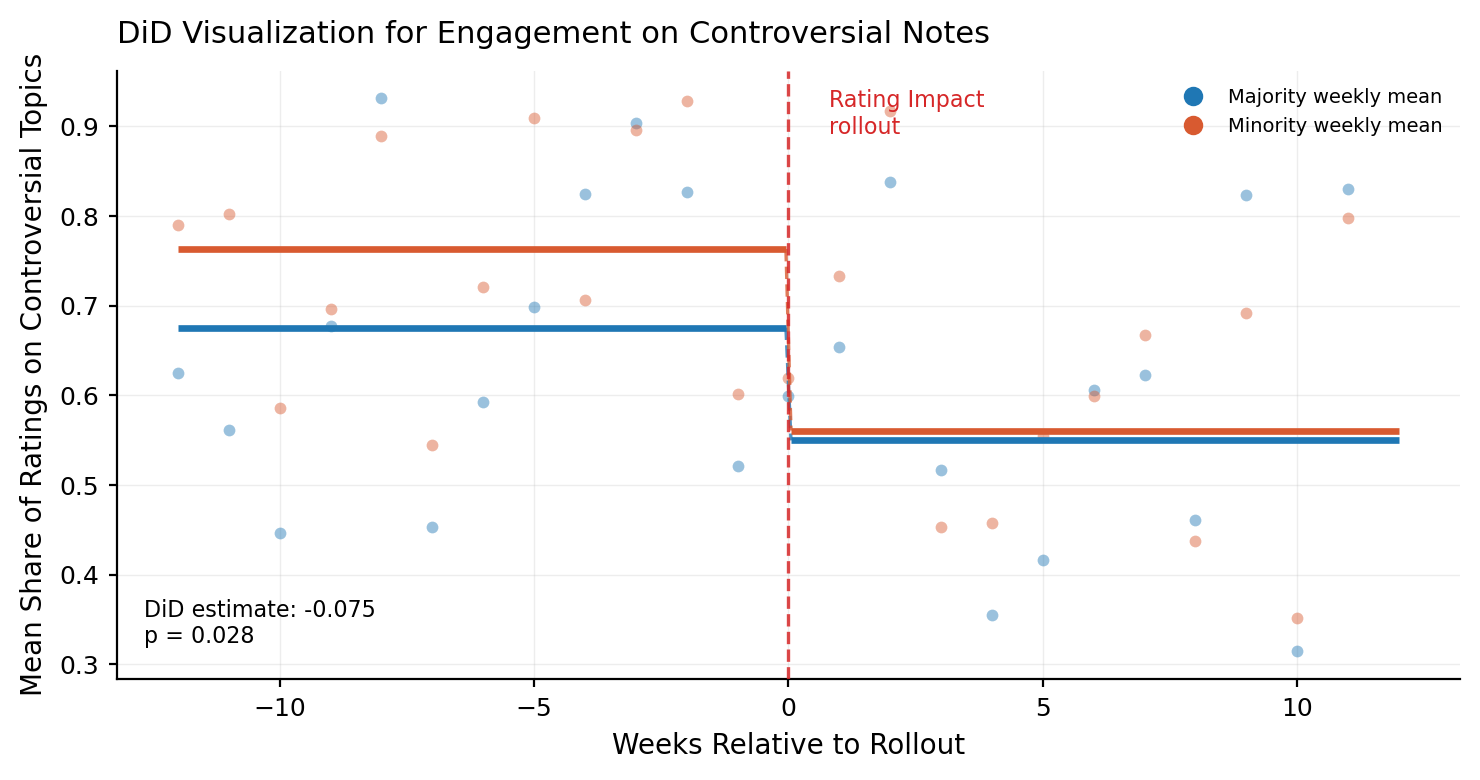

In [115]:
def run_did(df, outcome, minority_col, cutoff_date, window_weeks=12):
    d = df.copy()
    d["week_dt"] = pd.to_datetime(d["week_dt"])
    cutoff = pd.to_datetime(cutoff_date)

    lo = cutoff - pd.Timedelta(weeks=window_weeks)
    hi = cutoff + pd.Timedelta(weeks=window_weeks)
    d = d[(d["week_dt"] >= lo) & (d["week_dt"] < hi)].copy()
    d = d[d[minority_col].notna()].copy()

    d["Post"] = (d["week_dt"] >= cutoff).astype(int)
    d["treat"] = d[minority_col] * d["Post"]

    panel = d.set_index(["user", "week_dt"]).sort_index()
    return PanelOLS.from_formula(
        f"{outcome} ~ 1 + treat + EntityEffects + TimeEffects",
        data=panel,
        drop_absorbed=True,
    ).fit(cov_type="clustered", cluster_entity=True)


def plot_did_points_and_fit(
    df,
    res,
    outcome="prop_controversial",
    minority_col="minority",
    cutoff_date=partial_rollout_date,
    window_weeks=12,
    title="DiD Visualization for Engagement on Controversial Notes",
    save_path=None,
):
    cutoff = pd.to_datetime(cutoff_date)

    d = df.copy()
    d["week_dt"] = pd.to_datetime(d["week_dt"])
    d = d[d[minority_col].notna()].copy()
    d = d[
        (d["week_dt"] >= cutoff - pd.Timedelta(weeks=window_weeks)) &
        (d["week_dt"] <= cutoff + pd.Timedelta(weeks=window_weeks))
    ].copy()

    d["Post"] = (d["week_dt"] >= cutoff).astype(int)
    d["group"] = np.where(d[minority_col].eq(1), "Minority", "Majority")
    d["rel_week"] = ((d["week_dt"] - cutoff).dt.days / 7).round().astype(int)

    weekly = d.groupby(["rel_week", "group"], as_index=False)[outcome].mean()
    did_means = d.groupby(["group", "Post"], as_index=False)[outcome].mean()

    colors = {"Majority": _C_BLUE, "Minority": _C_ORANGE}

    apply_publication_style()
    fig, ax = plt.subplots(figsize=(7.5, 4.0))

    for group in ["Majority", "Minority"]:
        sub = weekly[weekly["group"].eq(group)]

        ax.scatter(
            sub["rel_week"],
            sub[outcome],
            color=colors[group],
            alpha=0.45,
            s=18,
            linewidths=0,
            zorder=2,
        )

        gmeans = did_means[did_means["group"].eq(group)]
        pre_mean = gmeans.loc[gmeans["Post"].eq(0), outcome].iloc[0]
        post_mean = gmeans.loc[gmeans["Post"].eq(1), outcome].iloc[0]

        ax.hlines(pre_mean, -window_weeks, -0.05, color=colors[group], linewidth=2.4, zorder=4)
        ax.hlines(post_mean, 0.05, window_weeks, color=colors[group], linewidth=2.4, zorder=4)
        ax.plot(
            [-0.05, 0.05],
            [pre_mean, post_mean],
            color=colors[group],
            linewidth=1.2,
            linestyle="--",
            alpha=0.8,
            zorder=3,
        )

    did_coef = res.params["treat"]
    did_pval = res.pvalues["treat"]

    ax.axvline(0, color=_C_EVENT, linewidth=1.2, linestyle="--", alpha=0.85, zorder=5)
    ax.text(
        0.8,
        0.97,
        "Rating Impact\nrollout",
        color=_C_EVENT,
        fontsize=_FONT_ANNOT,
        va="top",
        ha="left",
        transform=ax.get_xaxis_transform(),
    )
    ax.text(
        0.02,
        0.05,
        f"DiD estimate: {did_coef:.3f}\np = {did_pval:.3f}",
        transform=ax.transAxes,
        fontsize=_FONT_ANNOT,
        ha="left",
        va="bottom",
    )

    legend_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor=_C_BLUE,
            markeredgecolor=_C_BLUE,
            markersize=6,
            label="Majority weekly mean",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor=_C_ORANGE,
            markeredgecolor=_C_ORANGE,
            markersize=6,
            label="Minority weekly mean",
        ),
    ]
    ax.legend(handles=legend_handles, frameon=False, fontsize=_FONT_LEGEND, loc="upper right")

    _setup_ax(ax)
    _finalize(
        fig,
        ax,
        xlabel="Weeks Relative to Rollout",
        ylabel="Mean Share of Ratings on Controversial Topics",
        title=title,
        save_path=save_path,
    )

    return weekly, did_means


figure4_did_res = run_did(
    did_engagement_df,
    outcome="prop_controversial",
    minority_col="minority",
    cutoff_date=partial_rollout_date,
    window_weeks=figure4_window_weeks,
)
print(figure4_did_res.summary)

figure4_weekly, figure4_did_means = plot_did_points_and_fit(
    did_engagement_df,
    figure4_did_res,
    outcome="prop_controversial",
    minority_col="minority",
    cutoff_date=partial_rollout_date,
    window_weeks=figure4_window_weeks,
    title="DiD Visualization for Engagement on Controversial Notes",
    save_path="/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main/did_prop_controversial_points_fit.png",
)


# Main Text Figure 5

Using metrics: /accounts/projects/jchayes/commnotes/commnotes-analysis/data_output/two_stage_weekly_output/job_3289717/weekly_metrics.csv


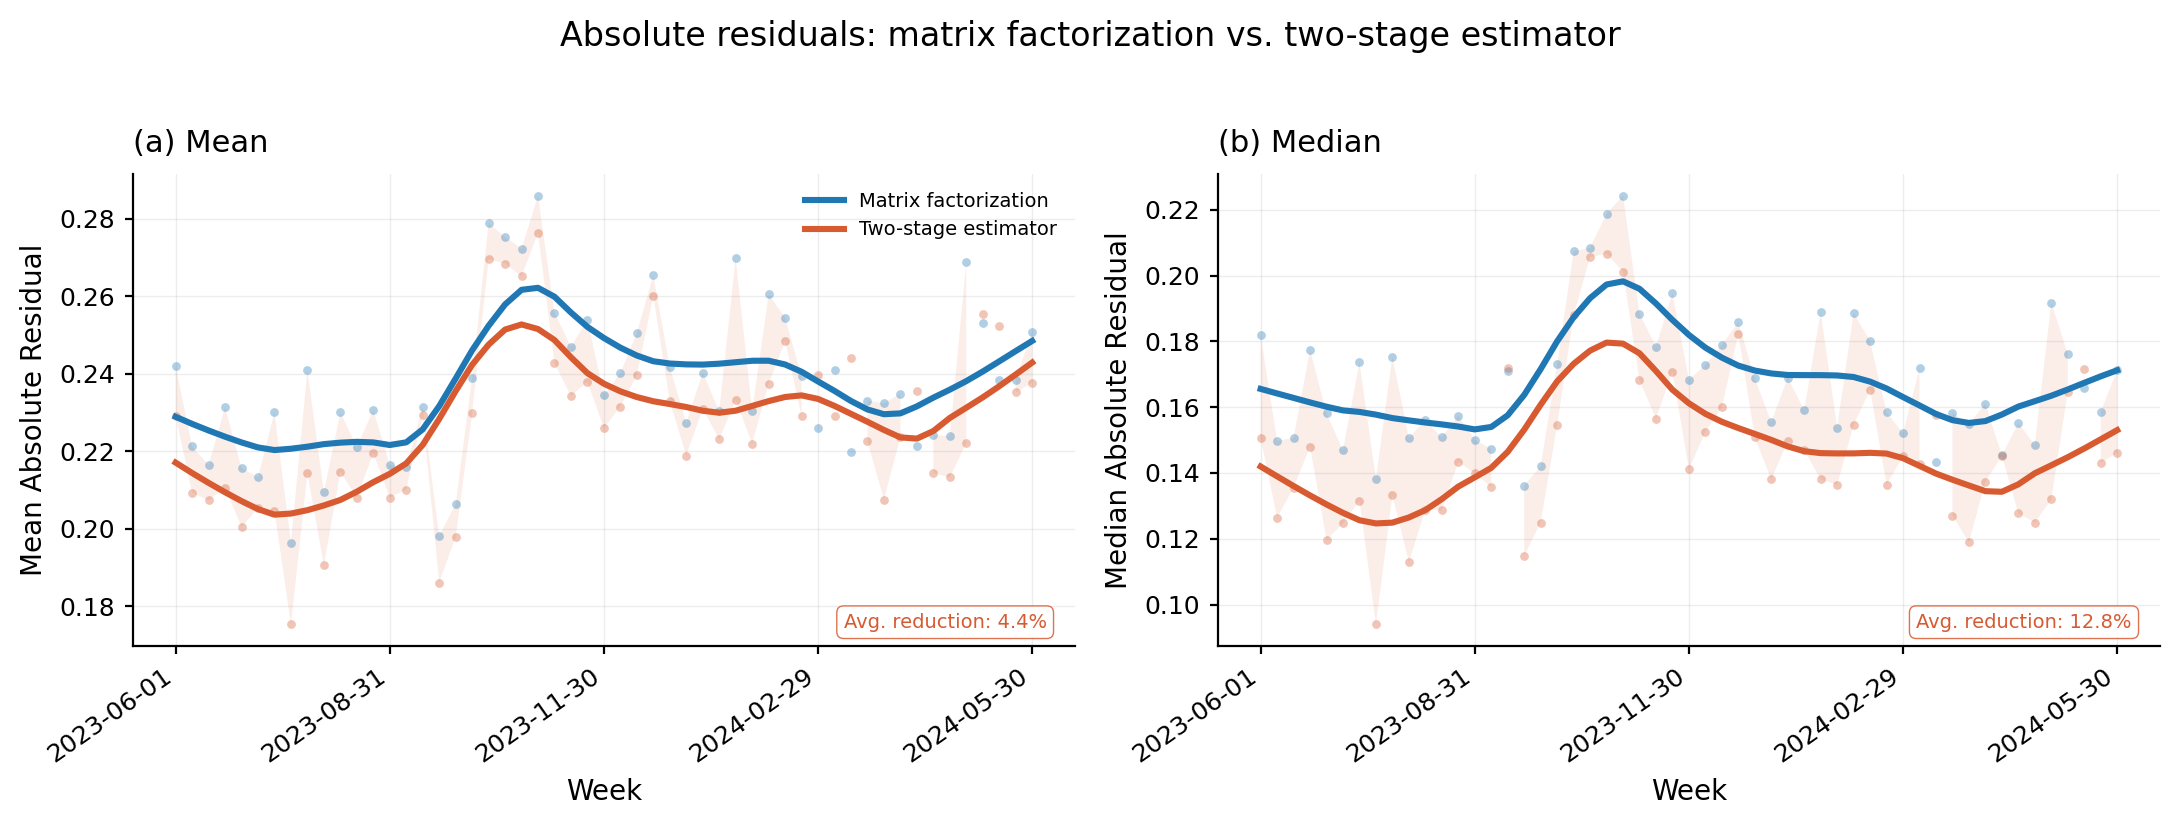

In [ ]:
REPO_ROOT = Path("/accounts/projects/jchayes/commnotes/commnotes-analysis")
sys.path.insert(0, str(REPO_ROOT / "analysis"))

from src.visualization import (
    apply_publication_style,
    _setup_ax,
    _finalize,
    _C_BLUE,
    _C_ORANGE,
    _FONT_LEGEND,
)

OUTPUT_ROOT = REPO_ROOT / "data_output/two_stage_weekly_output"

# Option A: use a specific run
# RUN_DIR = OUTPUT_ROOT / "plotting_metrics"
# METRICS_PATH = RUN_DIR / "weekly_metrics.csv"

# Option B: use the most recent completed run with weekly_metrics.csv
metrics_paths = sorted(
    OUTPUT_ROOT.glob("*/weekly_metrics.csv"),
    key=lambda p: p.stat().st_mtime,
)
if not metrics_paths:
    raise FileNotFoundError(f"No weekly_metrics.csv found under {OUTPUT_ROOT}")
METRICS_PATH = metrics_paths[-1]

weekly_metrics = pd.read_csv(METRICS_PATH)
print(f"Using metrics: {METRICS_PATH}")


def weekly_stats_from_metrics(metrics_df, model):
    out = metrics_df.loc[metrics_df["model"].eq(model)].copy()
    out["createdAtWeek"] = pd.to_datetime(out["fit_week"])

    # Match the old plot_abs_residual_comparison input shape.
    out = out.rename(
        columns={
            "mean_absolute_residual": "mean",
            "median_absolute_residual": "median",
            "exact_match_predictions": "count",
        }
    )

    keep = ["createdAtWeek", "mean", "median", "count"]
    out = out[keep].sort_values("createdAtWeek")

    # The new output is already weekly-aggregated, so std/se are not available
    # unless you save per-rating predictions.
    out["std"] = np.nan
    out["se"] = np.nan
    return out


weekly_stats1 = weekly_stats_from_metrics(weekly_metrics, "baseline_x_unweighted")
weekly_stats2 = weekly_stats_from_metrics(weekly_metrics, "low_rank_variance_weighted_x")


def plot_abs_residual_comparison(
    weekly_stats1,
    weekly_stats2,
    metrics=(("mean", "Mean Absolute Residual", "(a) Mean"),
             ("median", "Median Absolute Residual", "(b) Median")),
    save_path=REPO_ROOT / "figures/diagnostics/weekly_abs_residuals.png",
    title="Out-of-Sample Residuals: Matrix Factorization vs. Two-Stage Estimator",
):
    d1 = weekly_stats1.copy()
    d2 = weekly_stats2.copy()
    d1["createdAtWeek"] = pd.to_datetime(d1["createdAtWeek"])
    d2["createdAtWeek"] = pd.to_datetime(d2["createdAtWeek"])

    merged = d1.merge(
        d2,
        on="createdAtWeek",
        suffixes=("_mf", "_ts"),
    ).sort_values("createdAtWeek")
    merged["week_num"] = np.arange(len(merged))

    apply_publication_style()
    fig, axes = plt.subplots(1, len(metrics), figsize=(11, 4.0), sharex=True)
    if len(metrics) == 1:
        axes = [axes]

    for ax, (metric, ylabel, panel_title) in zip(axes, metrics):
        x = merged["week_num"].to_numpy(dtype=float)
        y_mf = merged[f"{metric}_mf"].to_numpy(dtype=float)
        y_ts = merged[f"{metric}_ts"].to_numpy(dtype=float)

        ax.fill_between(
            x, y_mf, y_ts,
            where=(y_mf >= y_ts),
            color=_C_ORANGE,
            alpha=0.10,
            linewidth=0,
        )
        ax.scatter(x, y_mf, s=10, color=_C_BLUE, alpha=0.35, linewidths=0, zorder=2)
        ax.scatter(x, y_ts, s=10, color=_C_ORANGE, alpha=0.35, linewidths=0, zorder=2)

        if len(x) >= 4:
            sm_mf = lowess(y_mf, x, frac=0.25, return_sorted=True)
            sm_ts = lowess(y_ts, x, frac=0.25, return_sorted=True)
            ax.plot(sm_mf[:, 0], sm_mf[:, 1], color=_C_BLUE, lw=2.2,
                    label="Matrix factorization")
            ax.plot(sm_ts[:, 0], sm_ts[:, 1], color=_C_ORANGE, lw=2.2,
                    label="Two-stage estimator")
        else:
            ax.plot(x, y_mf, color=_C_BLUE, lw=2.2, label="Matrix factorization")
            ax.plot(x, y_ts, color=_C_ORANGE, lw=2.2, label="Two-stage estimator")

        improvement = np.nanmean((y_mf - y_ts) / y_mf) * 100
        ax.text(
            0.97, 0.03,
            f"Avg. reduction: {improvement:.1f}%",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=_FONT_LEGEND,
            color=_C_ORANGE,
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=_C_ORANGE,
                      lw=0.5, alpha=0.85),
        )

        tick_idx = np.linspace(0, len(merged) - 1, min(5, len(merged)), dtype=int)
        tick_labels = merged.iloc[tick_idx]["createdAtWeek"].dt.strftime("%Y-%m-%d")
        ax.set_xticks(tick_idx)
        ax.set_xticklabels(tick_labels, rotation=35, ha="right")
        ax.set_xlabel("Week")
        ax.set_ylabel(ylabel)
        ax.set_title(panel_title, loc="left", pad=8)
        _setup_ax(ax)

    axes[0].legend(loc="upper right", frameon=False, fontsize=_FONT_LEGEND)
    _finalize(fig, axes, title=title, save_path=save_path)
    return merged


# 1. Two-panel figure: mean and median absolute residuals
weekly_residual_comparison_mean_median = plot_abs_residual_comparison(
    weekly_stats1,
    weekly_stats2,
    metrics=(
        ("mean", "Mean Absolute Residual", "(a) Mean"),
        ("median", "Median Absolute Residual", "(b) Median"),
    ),
    save_path=REPO_ROOT / "figures/main/weekly_abs_residuals_mean_median.png",
    title="One-Week-Ahead Residuals: Matrix Factorization vs. Two-Stage Estimator",
)

# [LEGACY] Main Text Figure 5

In [ ]:
# use the output from the two stage experiments
note_params_stage1 = pd.read_csv('/accounts/projects/jchayes/commnotes/analysis/two_stage/output_final/note_params_weekly_stage1_20251112_174832.csv')
rater_params_stage1 = pd.read_csv('/accounts/projects/jchayes/commnotes/analysis/two_stage/output_final/rater_params_weekly_stage1_20251112_174832.csv')
note_params_stage2 = pd.read_csv('/accounts/projects/jchayes/commnotes/analysis/two_stage/output_final/note_params_weekly_stage2_20251112_174832.csv')
rater_params_stage2 = pd.read_csv('/accounts/projects/jchayes/commnotes/analysis/two_stage/output_final/rater_params_weekly_stage2_20251112_174832.csv')

global_bias_stage1 = pd.read_csv('/accounts/projects/jchayes/commnotes/analysis/two_stage/output_final/global_bias_weekly_stage1_20251112_174832.csv')
global_bias_stage2 = pd.read_csv('/accounts/projects/jchayes/commnotes/analysis/two_stage/output_final/global_bias_weekly_stage2_20251112_174832.csv')

In [ ]:
ratings_df = read_ratings_from_directory(RATINGS_DIR, start_date_str="2023-01-01", end_date_str="2024-06-01")

In [ ]:
# Convert helpfulnessLevel to numeric helpfulNum
ratings_df['helpfulNum'] = None
ratings_df.loc[ratings_df['helpfulnessLevel'] == 'HELPFUL', 'helpfulNum'] = 1.0
ratings_df.loc[ratings_df['helpfulnessLevel'] == 'SOMEWHAT_HELPFUL', 'helpfulNum'] = 0.5
ratings_df.loc[ratings_df['helpfulnessLevel'] == 'NOT_HELPFUL', 'helpfulNum'] = 0.0

# Drop rows where helpfulNum is NaN (ratings with no helpfulness level)
ratings_df = ratings_df[ratings_df['helpfulNum'].notna()]
ratings_df['helpfulNum'] = ratings_df['helpfulNum'].astype(float)

# Match the weekly timestamp construction used in analyze_output.ipynb
ratings_df['createdAtDate'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms').dt.normalize()
ratings_df['createdAtWeek'] = ratings_df['createdAtDate'] - pd.to_timedelta(ratings_df['createdAtDate'].dt.dayofweek, unit='d')
ratings_df = ratings_df.sort_values(by='createdAtWeek')

In [ ]:
def merge_factors(ratings_df, note_df, rater_df):
    """
    Merge the most recent note and rater parameters for each rating using merge_asof.
    Uses factors from weeks strictly before the rating week.

    The returned dataframe keeps:
    - createdAtWeek: the rating week
    - noteFactorWeek: the week of the note parameters used
    - raterFactorWeek: the week of the rater parameters used
    """
    ratings_df = ratings_df.copy()
    ratings_df['createdAtWeek'] = pd.to_datetime(ratings_df['createdAtWeek'])
    note_df = note_df.copy()
    note_df['createdAtWeek'] = pd.to_datetime(note_df['createdAtWeek'])
    rater_df = rater_df.copy()
    rater_df['createdAtWeek'] = pd.to_datetime(rater_df['createdAtWeek'])

    ratings_df['noteId'] = ratings_df['noteId'].astype(str)
    ratings_df['raterParticipantId'] = ratings_df['raterParticipantId'].astype(str)
    note_df['noteId'] = note_df['noteId'].astype(str)
    rater_df['raterParticipantId'] = rater_df['raterParticipantId'].astype(str)

    note_df = note_df.rename(columns={'createdAtWeek': 'noteFactorWeek'})
    rater_df = rater_df.rename(columns={'createdAtWeek': 'raterFactorWeek'})

    ratings_df = ratings_df.sort_values('createdAtWeek')
    note_df = note_df.sort_values('noteFactorWeek')
    rater_df = rater_df.sort_values('raterFactorWeek')

    result = pd.merge_asof(
        ratings_df,
        note_df,
        left_on='createdAtWeek',
        right_on='noteFactorWeek',
        by='noteId',
        direction='backward',
        allow_exact_matches=False,
        suffixes=('', '_note')
    )

    result = pd.merge_asof(
        result.sort_values('createdAtWeek'),
        rater_df,
        left_on='createdAtWeek',
        right_on='raterFactorWeek',
        by='raterParticipantId',
        direction='backward',
        allow_exact_matches=False,
        suffixes=('', '_rater')
    )

    return result


In [ ]:
merged_df1 = merge_factors(ratings_df, note_params_stage1, rater_params_stage1)
merged_df2 = merge_factors(ratings_df, note_params_stage2, rater_params_stage2)

In [ ]:
merged_df1 = merged_df1.dropna()
merged_df2 = merged_df2.dropna()

In [ ]:
merged_df1.head()

In [ ]:
global_bias_stage1.head()

In [ ]:
# Merge global bias from the same MF week as the note parameters.
global_bias_stage1 = global_bias_stage1.copy()
global_bias_stage2 = global_bias_stage2.copy()
global_bias_stage1['noteFactorWeek'] = pd.to_datetime(global_bias_stage1['noteFactorWeek'])
global_bias_stage2['noteFactorWeek'] = pd.to_datetime(global_bias_stage2['noteFactorWeek'])

global_bias_stage1 = global_bias_stage1[['noteFactorWeek', 'globalBias']]
global_bias_stage2 = global_bias_stage2[['noteFactorWeek', 'globalBias']]

merged_df1 = merged_df1.merge(global_bias_stage1, on='noteFactorWeek', how='left')
merged_df2 = merged_df2.merge(global_bias_stage2, on='noteFactorWeek', how='left')


In [ ]:
merged_df1['helpfulEstimate'] = merged_df1['globalBias'] + merged_df1['raterIntercept'] + merged_df1['noteIntercept'] + merged_df1['raterFactor1'] * merged_df1['noteFactor1']
merged_df2['helpfulEstimate'] = merged_df2['globalBias'] + merged_df2['raterIntercept'] + merged_df2['noteIntercept'] + merged_df2['raterFactor1'] * merged_df2['noteFactor1']


In [ ]:
merged_df1['abs_residual'] = np.abs(merged_df1['helpfulNum'] - merged_df1['helpfulEstimate'])
merged_df2['abs_residual'] = np.abs(merged_df2['helpfulNum'] - merged_df2['helpfulEstimate'])


In [ ]:
# Compute mean and standard error by week for both dataframes
weekly_stats1 = merged_df1.groupby('createdAtWeek')['abs_residual'].agg(['mean', 'median', 'std', 'count']).reset_index()
weekly_stats1['se'] = weekly_stats1['std'] / np.sqrt(weekly_stats1['count'])

weekly_stats2 = merged_df2.groupby('createdAtWeek')['abs_residual'].agg(['mean', 'median', 'std', 'count']).reset_index()
weekly_stats2['se'] = weekly_stats2['std'] / np.sqrt(weekly_stats2['count'])


def plot_abs_residual_comparison(
    weekly_stats1,
    weekly_stats2,
    metrics=(('mean', 'Mean Absolute Residual', '(a) Mean'), ('median', 'Median Absolute Residual', '(b) Median')),
    save_path='/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/diagnostics/weekly_abs_residuals.png',
    title='Out-of-Sample Residuals: Matrix Factorization vs. Two-Stage Estimator',
):
    d1 = weekly_stats1.copy()
    d2 = weekly_stats2.copy()
    d1['createdAtWeek'] = pd.to_datetime(d1['createdAtWeek'])
    d2['createdAtWeek'] = pd.to_datetime(d2['createdAtWeek'])

    merged = d1.merge(
        d2,
        on='createdAtWeek',
        suffixes=('_mf', '_ts'),
    ).sort_values('createdAtWeek')
    merged['week_num'] = np.arange(len(merged))

    apply_publication_style()
    fig, axes = plt.subplots(1, len(metrics), figsize=(11, 4.0), sharex=True)
    if len(metrics) == 1:
        axes = [axes]

    for ax, (metric, ylabel, panel_title) in zip(axes, metrics):
        x = merged['week_num'].to_numpy(dtype=float)
        y_mf = merged[f'{metric}_mf'].to_numpy(dtype=float)
        y_ts = merged[f'{metric}_ts'].to_numpy(dtype=float)

        ax.fill_between(x, y_mf, y_ts, where=(y_mf >= y_ts), color=_C_ORANGE, alpha=0.10, linewidth=0)
        ax.scatter(x, y_mf, s=10, color=_C_BLUE, alpha=0.35, linewidths=0, zorder=2)
        ax.scatter(x, y_ts, s=10, color=_C_ORANGE, alpha=0.35, linewidths=0, zorder=2)

        if len(x) >= 4:
            sm_mf = lowess(y_mf, x, frac=0.25, return_sorted=True)
            sm_ts = lowess(y_ts, x, frac=0.25, return_sorted=True)
            ax.plot(sm_mf[:, 0], sm_mf[:, 1], color=_C_BLUE, lw=2.2, label='Matrix factorization (current)')
            ax.plot(sm_ts[:, 0], sm_ts[:, 1], color=_C_ORANGE, lw=2.2, label='Two-stage weighted (proposed)')
        else:
            ax.plot(x, y_mf, color=_C_BLUE, lw=2.2, label='Matrix factorization (current)')
            ax.plot(x, y_ts, color=_C_ORANGE, lw=2.2, label='Two-stage weighted (proposed)')

        improvement = np.nanmean((y_mf - y_ts) / y_mf) * 100
        ax.text(
            0.97,
            0.03,
            f'Avg. reduction: {improvement:.1f}%',
            transform=ax.transAxes,
            ha='right',
            va='bottom',
            fontsize=_FONT_LEGEND,
            color=_C_ORANGE,
            bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=_C_ORANGE, lw=0.5, alpha=0.85),
        )

        tick_idx = np.linspace(0, len(merged) - 1, min(5, len(merged)), dtype=int)
        tick_labels = merged.iloc[tick_idx]['createdAtWeek'].dt.strftime('%Y-%m-%d')
        ax.set_xticks(tick_idx)
        ax.set_xticklabels(tick_labels, rotation=35, ha='right')
        ax.set_xlabel('Week')
        ax.set_ylabel(ylabel)
        ax.set_title(panel_title, loc='left', pad=8)
        _setup_ax(ax)

    axes[0].legend(loc='upper right', frameon=False, fontsize=_FONT_LEGEND)
    _finalize(fig, axes, title=title, save_path=save_path)
    return merged


weekly_residual_comparison = plot_abs_residual_comparison(
    weekly_stats1,
    weekly_stats2,
    save_path='/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main/weekly_abs_residuals.png',
)

In [ ]:
# Compute mean and standard error by week for both dataframes
weekly_stats1 = merged_df1.groupby('createdAtWeek')['abs_residual'].agg(['mean', 'median', 'std', 'count']).reset_index()
weekly_stats1['se'] = weekly_stats1['std'] / np.sqrt(weekly_stats1['count'])

weekly_stats2 = merged_df2.groupby('createdAtWeek')['abs_residual'].agg(['mean', 'median', 'std', 'count']).reset_index()
weekly_stats2['se'] = weekly_stats2['std'] / np.sqrt(weekly_stats2['count'])

plot_abs_residual_comparison(
    weekly_stats1,
    weekly_stats2,
    metrics=(('mean', 'Mean absolute residual', 'Mean'),),
    save_path='/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main/weekly_abs_residuals_mean.png',
    title='Mean absolute residuals: matrix factorization vs. two-stage estimator',
)

plot_abs_residual_comparison(
    weekly_stats1,
    weekly_stats2,
    metrics=(('median', 'Median Absolute Residual', 'Median'),),
    save_path='/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main/weekly_abs_residuals_median.png',
    title='Median absolute residuals: matrix factorization vs. two-stage estimator',
)